# Asset Statistical Pipeline — INTARIAN_PEPPER_ROOT

Parameterized diagnostic + alpha pipeline for a single asset.

**Pipeline:**
```
Config → Load → Stationarity → Drift → ACF/PACF → FFT → Hurst → VR → AR
       → Features → Alpha Score → Backtest → Risk/Inventory → Sensitivity
```


## 0. Configuration — edit here only

In [1]:
# ── Asset ──────────────────────────────────────────────────────────────────
PRODUCT     = "INTARIAN_PEPPER_ROOT"
DATA_DIR    = "../dataset/ROUND_1"
FILE_PREFIX = "prices_round_1_day_"
DAY_RANGE   = [-2, -1, 0]

# ── Spread mode ────────────────────────────────────────────────────────────
IS_SPREAD      = False
BASKET_PRODUCT = ""
SYNTH_WEIGHTS  = {}
SPREAD_LABEL   = ""

# ── Statistical diagnostics ────────────────────────────────────────────────
N_WINDOW    = 20
N_LAGS_ACF  = 40
LB_LAGS     = [1, 2, 3, 5, 10, 20]
HURST_NMAX  = 100
VR_LAGS     = [2, 4, 8, 16]
AR_MAX_P    = 10
FFT_TOP_N   = 5

# ── Strategy ───────────────────────────────────────────────────────────────
POS_LIMIT       = 300
UNIT_SIZE       = 1
ENTRY_THRESHOLD = 0.35
EXIT_THRESH     = 0.05
SIG_WEIGHTS     = {"sig_zscore": 0.40, "sig_rsi": 0.25,
                   "sig_bb":     0.25, "sig_macd": 0.10}

# ── Risk / inventory ───────────────────────────────────────────────────────
SOFT_LIMIT  = 210
MTM_PAIN    = -500
STALE_BARS  = 200
ROLL_W      = 200

## 1. Imports & Helpers

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, acovf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.ar_model import AutoReg

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

# ── Indicator library ──────────────────────────────────────────────────────
def sma(s, n):       return s.rolling(n).mean()
def ema(s, n):       return s.ewm(span=n, adjust=False).mean()

def rsi(s, n=14):
    d = s.diff()
    g = d.clip(lower=0).rolling(n).mean()
    l = (-d.clip(upper=0)).rolling(n).mean()
    return 100 - 100 / (1 + g / l.replace(0, np.nan))

def macd(s, fast=12, slow=26, sig=9):
    line = ema(s, fast) - ema(s, slow)
    signal = ema(line, sig)
    return line, signal, line - signal

def bollinger(s, n=20, k=2):
    mid = sma(s, n); std = s.rolling(n).std()
    return mid - k*std, mid, mid + k*std

def zscore(s, n=20):
    return (s - s.rolling(n).mean()) / s.rolling(n).std().replace(0, np.nan)

def momentum(s, n=10): return s - s.shift(n)

print("Imports OK")

Imports OK


## 2. Load Data

In [3]:
dfs = []
for day in DAY_RANGE:
    path = f"{DATA_DIR}/{FILE_PREFIX}{day}.csv"
    df = pd.read_csv(path, sep=";")
    df["day"] = day
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)
prices["t"] = prices["day"] * 1_000_000 + prices["timestamp"]

def get_mid(product):
    sub = prices[prices["product"] == product][["t", "mid_price"]].set_index("t")
    mid = sub["mid_price"]
    # Empty order-book ticks (no bid, no ask) are recorded as mid_price=0.
    # Treat these as missing observations rather than real price drops.
    return mid.replace(0, np.nan)

if IS_SPREAD:
    basket = get_mid(BASKET_PRODUCT)
    components = {p: get_mid(p) for p in SYNTH_WEIGHTS}
    common = basket.index
    for s in components.values(): common = common.intersection(s.index)
    basket = basket.loc[common]
    synthetic = sum(w * components[p].loc[common] for p, w in SYNTH_WEIGHTS.items())
    series = basket - synthetic
    series.name = f"{BASKET_PRODUCT} - Synthetic"
    price_series = basket   # for raw price plots
    print(f"Spread mean: {series.mean():.2f}  std: {series.std():.2f}")
else:
    series = get_mid(PRODUCT)
    price_series = series

series = series.dropna()
_pr = price_series  # zeros already NaN from get_mid()
log_ret = np.log(_pr / _pr.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()

print(f"Loaded {len(series):,} observations")
print(f"Price range: {series.min():.2f} – {series.max():.2f}")
print(f"Mean: {series.mean():.4f}  Std: {series.std():.4f}")

Loaded 29,946 observations
Price range: 9998.50 – 13007.00
Mean: 11499.8885  Std: 866.1071


## 3. Price Series Overview

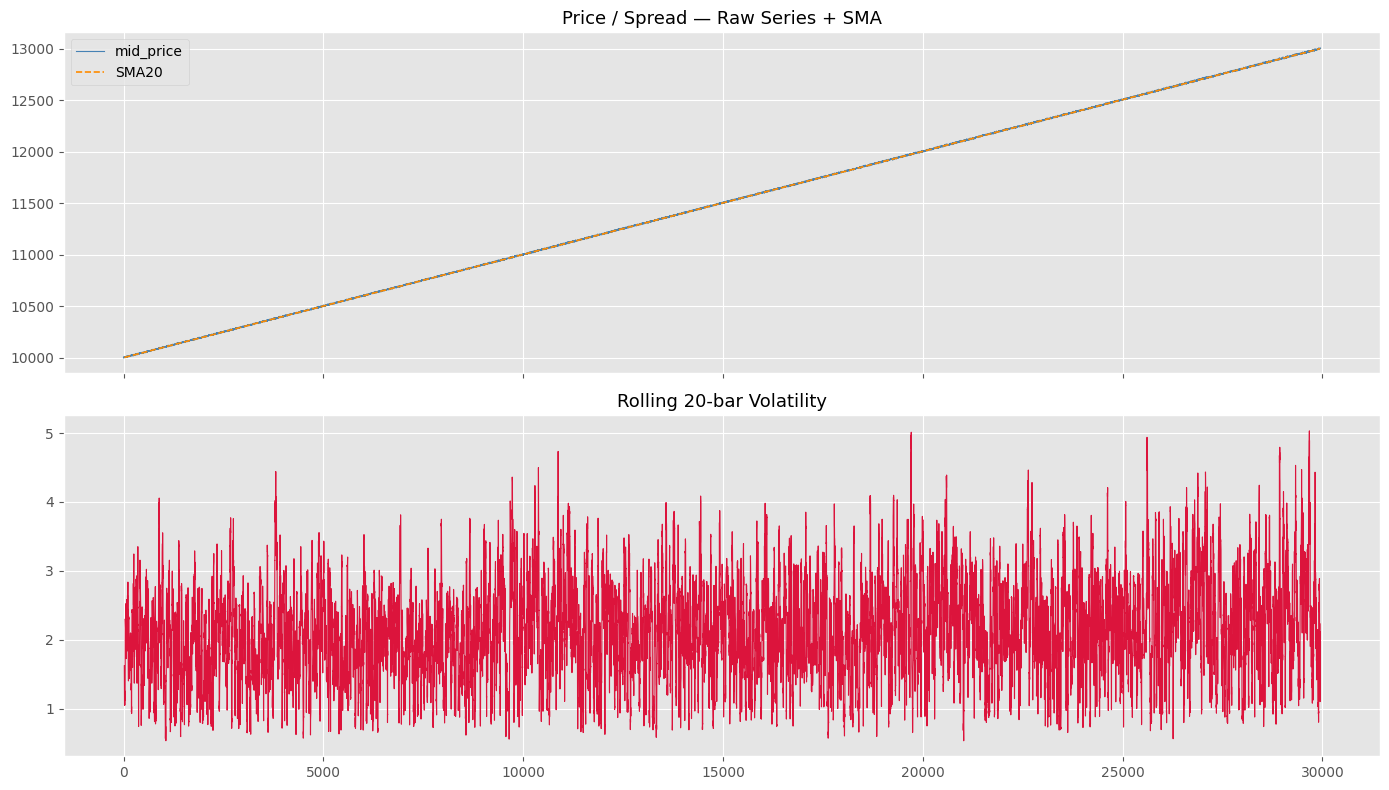

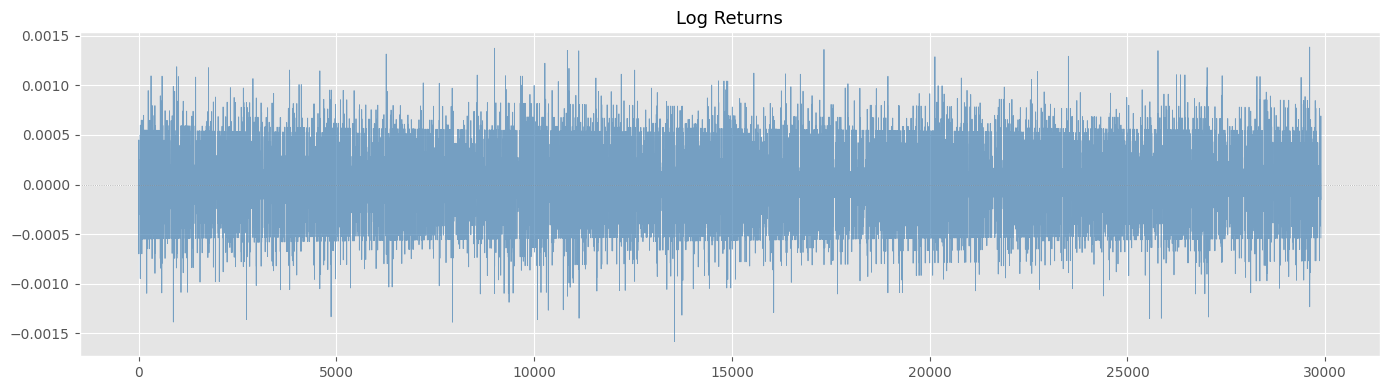

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(series.values, color='steelblue', linewidth=0.8, label=series.name or PRODUCT)
axes[0].plot(sma(series, N_WINDOW).values, color='darkorange', linewidth=1.2,
             linestyle='--', label=f'SMA{N_WINDOW}')
axes[0].set_title('Price / Spread — Raw Series + SMA')
axes[0].legend()

vol = series.rolling(N_WINDOW).std()
axes[1].plot(vol.values, color='crimson', linewidth=0.8)
axes[1].set_title(f'Rolling {N_WINDOW}-bar Volatility')

plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(log_ret.values, color='steelblue', linewidth=0.6, alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set_title('Log Returns')
plt.tight_layout(); plt.show()

## 4. Stationarity Tests — ADF + KPSS

### Theory

A series is **stationary** if its mean, variance, and autocovariance are constant over time. Stationarity is a prerequisite for most time-series models and mean-reversion strategies.

Two complementary tests with opposite null hypotheses:

**Augmented Dickey-Fuller (ADF)**
- **H₀:** The series has a unit root (non-stationary, random walk)
- **H₁:** The series is stationary
- Low p-value (< 0.05) → reject H₀ → evidence of stationarity

**KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**
- **H₀:** The series is stationary (or trend-stationary)
- **H₁:** The series has a unit root
- Low p-value (< 0.05) → reject H₀ → evidence of non-stationarity

Using both together removes ambiguity:

| Result | ADF p | KPSS p | Interpretation |
|--------|-------|--------|----------------|
| Stationary I(0) | < 0.05 | > 0.05 | Mean-reversion viable on raw price |
| Unit root I(1) | > 0.05 | < 0.05 | Model returns, not price levels |
| Trend-stationary | > 0.05 | > 0.05 | Detrend first, then re-test |
| Ambiguous | < 0.05 | < 0.05 | Conflicting evidence — check visually |

### Interpretation

**If price levels are non-stationary but returns are stationary** → the price series is **I(1)** (integrated of order 1), which is the standard result for financial prices:
- Analyse and model **returns**, not raw prices
- Mean-reversion strategies should operate on *deviations from a spread or moving average*, not on the raw price itself

**If price levels are stationary** → prices gravitate to a long-run mean. Mean-reversion strategies on the raw price may be directly viable.

**Trend-stationary** → subtract a fitted linear trend from the price, then re-test. The detrended residuals may be stationary.


In [5]:
def run_adf_kpss(s, label='series'):
    adf_stat, adf_p, _, _, adf_cv, _ = adfuller(s.dropna(), autolag='AIC')
    try:
        kpss_stat, kpss_p, _, kpss_cv = kpss(s.dropna(), regression='c', nlags='auto')
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    stationary_adf  = adf_p  < 0.05
    stationary_kpss = kpss_p > 0.05

    print(f"\n{'═'*55}")
    print(f"  Stationarity Tests — {label}")
    print(f"{'═'*55}")
    print(f"  ADF  stat={adf_stat:>9.4f}  p={adf_p:.4f}  "
          f"{'[STATIONARY ✓]' if stationary_adf else '[UNIT ROOT ✗]'}")
    print(f"  KPSS stat={kpss_stat:>9.4f}  p={kpss_p:.4f}  "
          f"{'[STATIONARY ✓]' if stationary_kpss else '[NON-STAT  ✗]'}")

    if stationary_adf and stationary_kpss:
        verdict = "I(0) — stationary  ✅  Mean-reversion strategies applicable"
    elif not stationary_adf and not stationary_kpss:
        verdict = "I(1) — unit root   ❌  Difference the series before modelling"
    else:
        verdict = "Ambiguous — inspect visually or test on differences"
    print(f"\n  Verdict: {verdict}")
    return adf_p, kpss_p

label = f"{BASKET_PRODUCT} - Synthetic" if IS_SPREAD else PRODUCT
adf_p_level, kpss_p_level = run_adf_kpss(series,   label=f'{label} (levels)')
adf_p_ret,   kpss_p_ret   = run_adf_kpss(log_ret,  label=f'{label} (log-returns)')

C:\Users\fogat\AppData\Local\Temp\ipykernel_19364\691036138.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_cv = kpss(s.dropna(), regression='c', nlags='auto')



═══════════════════════════════════════════════════════
  Stationarity Tests — INTARIAN_PEPPER_ROOT (levels)
═══════════════════════════════════════════════════════
  ADF  stat=   0.0252  p=0.9606  [UNIT ROOT ✗]
  KPSS stat=  29.7496  p=0.0100  [NON-STAT  ✗]

  Verdict: I(1) — unit root   ❌  Difference the series before modelling

═══════════════════════════════════════════════════════
  Stationarity Tests — INTARIAN_PEPPER_ROOT (log-returns)
═══════════════════════════════════════════════════════
  ADF  stat= -42.0405  p=0.0000  [STATIONARY ✓]
  KPSS stat=   0.4162  p=0.0702  [STATIONARY ✓]

  Verdict: I(0) — stationary  ✅  Mean-reversion strategies applicable


## 5. Drift Detection — OLS Trend

### Theory

**Drift** is a systematic directional bias — the series tends to move up (or down) on average each step. It is distinct from a random walk, where direction at each step is unpredictable.

We test drift by fitting a linear trend:
$$p_t = \alpha + \beta \cdot t + \varepsilon_t$$

- **β** is the drift coefficient: the expected change in price per time step
- **t-statistic on β**: if |t| > 2 and p < 0.05 → drift is statistically significant
- **R²**: how much price variance is explained by the linear trend alone

We also inspect **rolling mean behaviour** — a drifting series has a rolling mean that systematically moves in one direction rather than fluctuating around a constant level.

### Interpretation

| Result | Meaning |
|---|---|
| Significant β, high R² | Strong deterministic trend — prices follow a predictable slope |
| Significant β, low R² | Weak drift overwhelmed by noise |
| Non-significant β | No evidence of drift — price has no long-run directional bias |
| Residuals look stationary | After removing the trend, the series may be stationary (trend-stationary) |
| Residuals still wander | Stochastic non-stationarity remains even after detrending |

> **Trading implication:** Significant drift in the competition window may be exploitable by a directional bias, but drift can be short-lived. Always combine with stationarity tests before acting on it.


OLS drift: slope=0.100188, p=0.0000, R²=1.0000
  → Significant upward drift detected ⚠


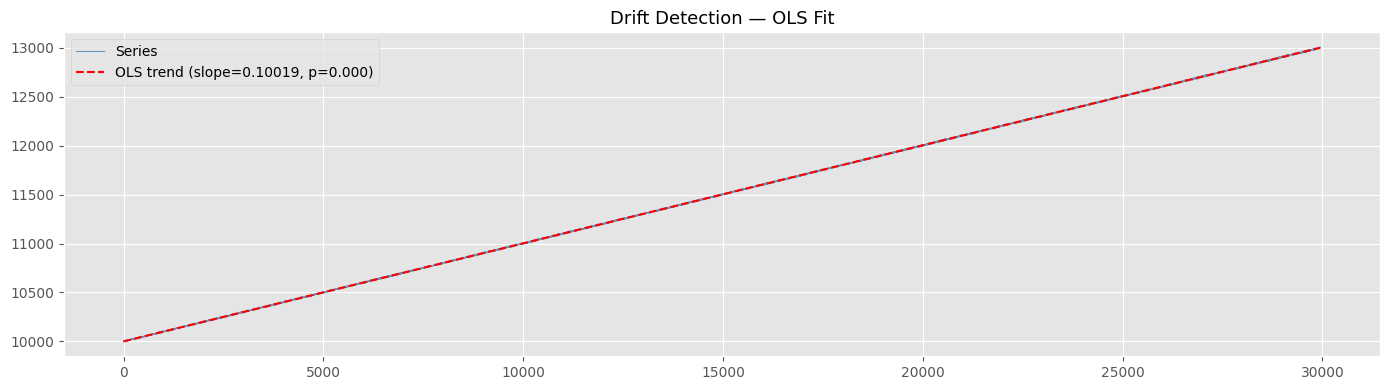

In [6]:
series = series.replace([np.inf, -np.inf], np.nan).dropna()
t_idx = np.arange(len(series))
X = sm.add_constant(t_idx)
ols = sm.OLS(series.values, X).fit()
slope, slope_pval = ols.params[1], ols.pvalues[1]

print(f"OLS drift: slope={slope:.6f}, p={slope_pval:.4f}, R²={ols.rsquared:.4f}")
if slope_pval < 0.05:
    print(f"  → Significant {'upward' if slope > 0 else 'downward'} drift detected ⚠")
else:
    print("  → No significant drift — zero-drift assumption holds ✅")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series.values, color='steelblue', linewidth=0.8, label='Series', alpha=0.8)
ax.plot(ols.fittedvalues, color='red', linewidth=1.5, linestyle='--',
        label=f'OLS trend (slope={slope:.5f}, p={slope_pval:.3f})')
ax.set_title('Drift Detection — OLS Fit')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Autocorrelation — ACF / PACF / Ljung-Box

### Theory

**Autocorrelation at lag k** measures the linear correlation between `y_t` and `y_{t-k}`:
$$\rho_k = \frac{\text{Cov}(y_t,\, y_{t-k})}{\text{Var}(y_t)}$$

In an efficient market, returns should have zero autocorrelation — past prices carry no information about future prices. Departures from zero are potentially exploitable signals.

**ACF (Autocorrelation Function)**
Plots ρ_k for all lags k. Includes *indirect* effects through intermediate lags.

**PACF (Partial ACF)**
Plots the correlation at lag k *after removing* the effect of lags 1 through k−1.
Key for identifying AR order: if PACF cuts off sharply at lag p → AR(p) process.

**Ljung-Box Test**
Formal joint test: are *all* autocorrelations up to lag k simultaneously zero?
- **H₀:** No autocorrelation up to lag k
- Low p-value → significant serial correlation present

Confidence bands in ACF/PACF plots are ±1.96/√N — spikes outside these are significant at the 5% level.

### ACF pattern → process type

| ACF shape | PACF shape | Likely model |
|---|---|---|
| Decays slowly (geometrically) | Sharp cutoff at lag p | AR(p) |
| Sharp cutoff at lag q | Decays slowly | MA(q) |
| Both decay slowly | Both decay slowly | ARMA(p,q) |
| All near zero | All near zero | White noise (efficient market) |
| Decays very slowly (hyperbolic) | Same | Long-memory process |
| Oscillates with period k | Peaks at multiples of k | Cyclical / seasonal |

**Ljung-Box:** Significance at short lags (5–10) indicates economically relevant autocorrelation. Significance only at long lags may be noise or model mis-specification.


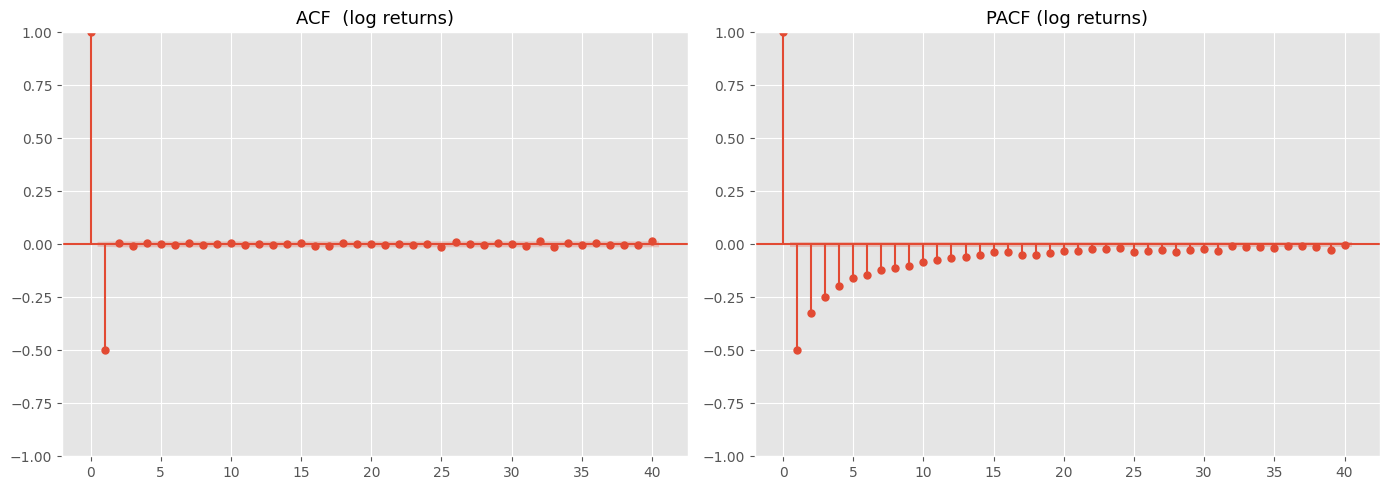


Ljung-Box test on log-returns:
       Q-stat  p-value
1   7433.1961      0.0
2   7434.1169      0.0
3   7437.0287      0.0
5   7437.8411      0.0
10  7441.1507      0.0
20  7446.9302      0.0
  → Significant autocorrelation at lags: [1, 2, 3, 5, 10, 20] ⚠


In [7]:
ret_arr = log_ret.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sm.graphics.tsa.plot_acf( ret_arr, lags=N_LAGS_ACF, ax=axes[0], title='ACF  (log returns)',  alpha=0.05)
sm.graphics.tsa.plot_pacf(ret_arr, lags=N_LAGS_ACF, ax=axes[1], title='PACF (log returns)', alpha=0.05)
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(ret_arr, lags=LB_LAGS, return_df=True)
print("\nLjung-Box test on log-returns:")
print(lb.rename(columns={'lb_stat':'Q-stat','lb_pvalue':'p-value'}).round(4).to_string())
sig_lbs = lb[lb['lb_pvalue'] < 0.05]
if len(sig_lbs):
    print(f"  → Significant autocorrelation at lags: {list(sig_lbs.index)} ⚠")
else:
    print("  → No significant autocorrelation — returns are close to i.i.d. ✅")

## 7. Cyclicality — FFT Periodogram

### Theory

**Fourier analysis** decomposes a time series into a sum of sine and cosine waves at different frequencies. If a particular frequency dominates, the series contains a **periodic cycle** at that wavelength.

The **periodogram** plots power (squared amplitude) against frequency:
- A peak at frequency f → a cycle with period T = N/f (or 1/f if frequency is in cycles-per-step)
- Flat periodogram → no dominant cycle (consistent with white noise)

We apply the FFT to:
1. **Detrended prices** — to find structural price cycles
2. **Returns** — to find return-predictability cycles

> **Important:** Always detrend before FFT. A strong trend injects power at all low frequencies and masks real cycles.

### Interpretation

| Periodogram shape | Meaning |
|---|---|
| Flat, no dominant peak | No cyclical structure — consistent with white noise |
| One dominant sharp peak at period T | Clear cycle of length T steps |
| Multiple peaks at T, T/2, T/3 | Harmonic structure (strong fundamental cycle) |
| Power concentrated at low frequencies | Long, slow cycles / trend-like behaviour |
| Power decays as power law in frequency | Possible long-memory or fractal structure |

> **Competition implication:** A cycle of period T in returns means the price completes one mean-reversion cycle every T steps on average. This directly informs entry/exit timing.
> **Caveat:** Always verify that the same cycle appears in different sub-windows of the data before trading on it.


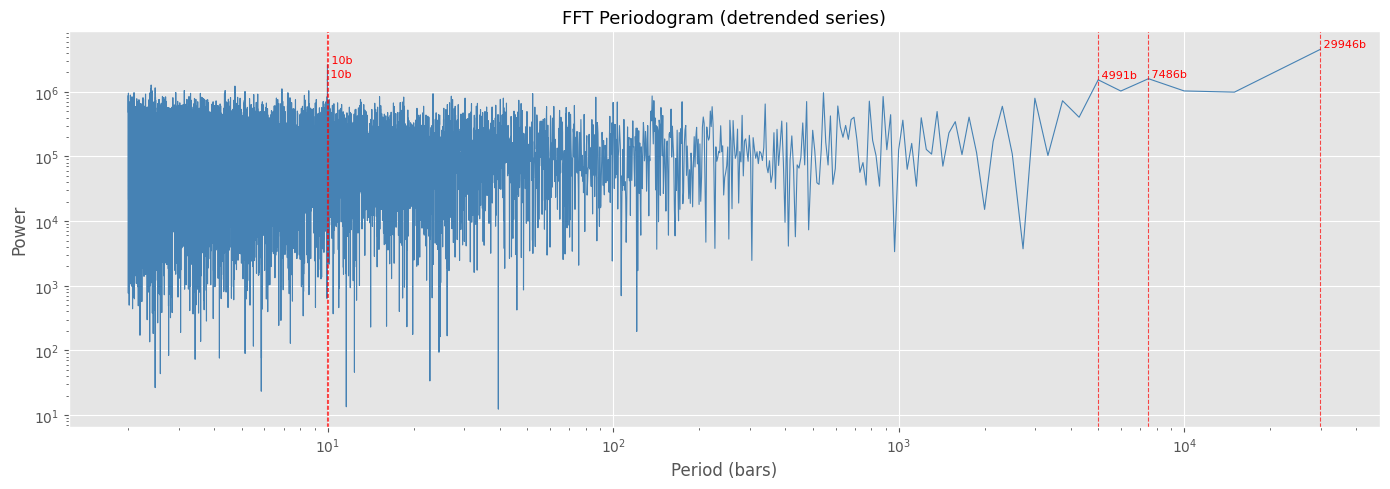

Top 5 dominant periods (bars): 29946, 10, 7486, 10, 4991


In [8]:
detrended = series.values - ols.fittedvalues
N = len(detrended)
fft_vals  = np.fft.rfft(detrended)
freqs     = np.fft.rfftfreq(N)
power     = np.abs(fft_vals)**2

# exclude DC component
pos = freqs > 0
freqs_pos, power_pos = freqs[pos], power[pos]
periods = 1.0 / freqs_pos

top_idx = np.argsort(power_pos)[-FFT_TOP_N:][::-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.loglog(periods, power_pos, color='steelblue', linewidth=0.8)
for i in top_idx:
    ax.axvline(periods[i], color='red', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.text(periods[i], power_pos[i], f' {periods[i]:.0f}b', fontsize=8,
            color='red', va='bottom')
ax.set_xlabel('Period (bars)'); ax.set_ylabel('Power')
ax.set_title('FFT Periodogram (detrended series)')
plt.tight_layout(); plt.show()

print(f"Top {FFT_TOP_N} dominant periods (bars): "
      + ", ".join(f"{periods[i]:.0f}" for i in top_idx))

## 8. Hurst Exponent — R/S Analysis

### Theory

The **Hurst Exponent H** characterises the *memory* and *self-similarity* of a time series:

| H | Process type | Behaviour | Strategy |
|---|---|---|---|
| H < 0.5 | Anti-persistent / mean-reverting | Reversals more likely | Fade moves, Bollinger Bands, OU model |
| H ≈ 0.5 | Random walk | No memory — efficient market | No statistical edge |
| H > 0.5 | Persistent / trending | Trends persist | Momentum, MA crossovers |

#### R/S (Rescaled Range) Method

For a window of size n:
1. Compute cumulative deviations from the mean: `Z_t = Σ(r_i − r̄)`
2. Range: `R = max(Z) − min(Z)`
3. Std dev: `S = std(r)`
4. Rescaled range: `R/S`

Repeat over many window sizes n. For a fractal process: `E[R/S] ~ c · n^H`

Taking logs: `log(R/S) = log(c) + H · log(n)`

**H is the slope** of log(R/S) vs log(n), estimated via OLS regression.

### Interpretation

- **The log-log plot should be approximately linear.** Curvature suggests regime changes or non-constant memory.
- **Compare the fitted slope to the H = 0.5 dashed line.** Does the data clearly depart from a random walk?
- **R² of the regression:** Should be > 0.95 for a reliable estimate. Low R² means R/S scaling is noisy — treat H with scepticism.
- **Confidence interval:** If the interval contains 0.5, you cannot statistically rule out a random walk.

> **Practical note:** R/S analysis is sensitive to short-range autocorrelation. For a more robust estimate, consider DFA (Detrended Fluctuation Analysis) as an alternative.


Hurst exponent H = 1.1921  (R²=0.9892)
Regime: Trending ⚠


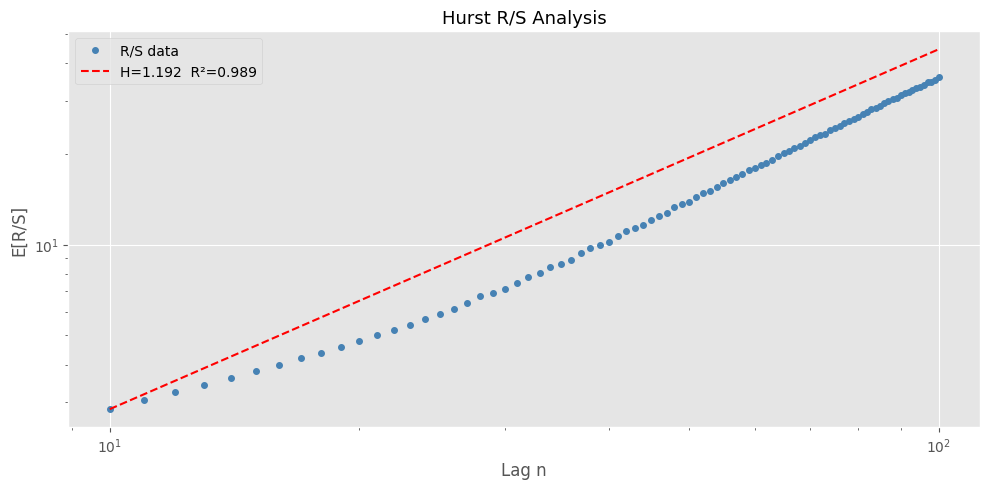

In [9]:
def hurst_rs(ts, n_max=None):
    ts = np.asarray(ts, dtype=float)
    ts = ts[~np.isnan(ts)]
    N  = len(ts)
    if n_max is None: n_max = N // 2
    lags, rs_vals = [], []
    for n in range(10, min(n_max, N//2)+1, max(1, (min(n_max, N//2)-10)//50)):
        chunks = [ts[i:i+n] for i in range(0, N-n+1, n)]
        rs_chunk = []
        for chunk in chunks:
            mean  = chunk.mean()
            dev   = np.cumsum(chunk - mean)
            R     = dev.max() - dev.min()
            S     = chunk.std(ddof=1)
            if S > 0: rs_chunk.append(R / S)
        if rs_chunk:
            lags.append(n); rs_vals.append(np.mean(rs_chunk))
    lags, rs_vals = np.array(lags), np.array(rs_vals)
    log_n, log_rs = np.log(lags), np.log(rs_vals)
    H, _ = np.polyfit(log_n, log_rs, 1)
    ss_res = np.sum((log_rs - np.polyval([H, _], log_n))**2)
    ss_tot = np.sum((log_rs - log_rs.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return H, r2, lags, rs_vals

H, r2, lags, rs_vals = hurst_rs(series.values, n_max=HURST_NMAX)
regime = "Mean-reverting ✅" if H < 0.45 else ("Random walk" if H < 0.55 else "Trending ⚠")
print(f"Hurst exponent H = {H:.4f}  (R²={r2:.4f})")
print(f"Regime: {regime}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(lags, rs_vals, 'o', color='steelblue', markersize=4, label='R/S data')
fit_line = np.exp(np.polyval([H, np.log(rs_vals[0]) - H*np.log(lags[0])], np.log(lags)))
ax.loglog(lags, fit_line, '--', color='red', label=f'H={H:.3f}  R²={r2:.3f}')
ax.set_xlabel('Lag n'); ax.set_ylabel('E[R/S]')
ax.set_title('Hurst R/S Analysis')
ax.legend(); plt.tight_layout(); plt.show()

## 9. Variance Ratio Test — Lo-MacKinlay

### Theory

The **Variance Ratio (VR) test** (Lo & MacKinlay, 1988) tests whether a series is consistent with a random walk.

**Key insight:** For a random walk, variance grows *linearly* with time:
$$\text{Var}(r_t + r_{t+1} + \ldots + r_{t+k-1}) = k \cdot \text{Var}(r_t)$$

The variance ratio is:
$$\text{VR}(k) = \frac{\text{Var}(k\text{-period returns})}{k \cdot \text{Var}(1\text{-period returns})}$$

Under a pure random walk, VR(k) = 1 for all k.

| VR(k) | Autocorrelation | Implication |
|---|---|---|
| > 1 | Positive at horizon k | Momentum — trends persist |
| < 1 | Negative at horizon k | Mean-reversion — reversals likely |
| = 1 | Zero | Random walk — no exploitable structure |

Testing at *multiple horizons* k reveals at which time scales structure exists.

### Interpretation

- **VR profile consistently below 1:** Mean-reverting at all horizons → stat-arb / fade-the-move strategies.
- **VR profile consistently above 1:** Trending at all horizons → momentum strategies.
- **VR < 1 at short k, VR > 1 at long k:** Short-term mean-reversion, long-term trend — typical of real prices. Use tight holding periods.
- **VR ≈ 1 at all k:** Cannot reject the random walk — rely on other tests before trading.

> **Combine with Hurst:** Hurst gives one scalar; the VR profile shows *at which horizons* the effect is strongest — crucial for sizing your trade holding period.


   Lag k       VR     z-stat               Regime
--------------------------------------------------
       2   0.5013   -86.2222       Mean-reverting
       4   0.2526   -69.0741       Mean-reverting
       8   0.1272   -51.0137       Mean-reverting
      16   0.0657   -36.6991       Mean-reverting


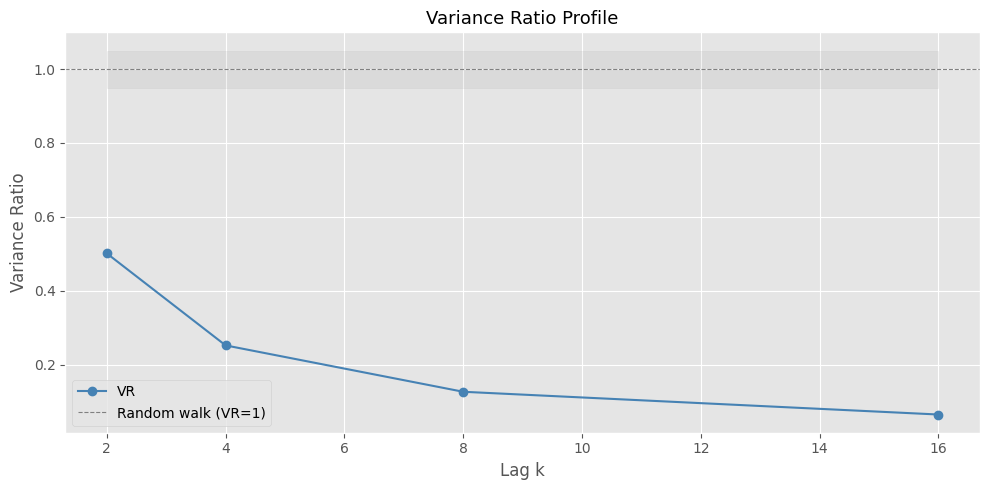

In [10]:
def variance_ratio(ret, k):
    """Heteroskedasticity-robust VR test (Lo-MacKinlay 1988)."""
    T  = len(ret)
    mu = ret.mean()
    # k-period returns
    ret_k = np.array([ret[i:i+k].sum() for i in range(T-k+1)])
    var1  = ((ret - mu)**2).sum() / (T - 1)
    vark  = ((ret_k - k*mu)**2).sum() / (len(ret_k) - 1) / k
    vr    = vark / var1
    # heteroskedasticity-robust z-stat
    delta = np.array([
        ((ret[j]**2) * (ret[j+1:j+k].sum())**2
         for j in range(T-k)) if False else 0
    ])
    # simplified z-stat (homoskedastic version)
    z = (vr - 1) / np.sqrt(2*(2*k - 1)*(k-1) / (3*k*T))
    return vr, z

ret_arr_vr = log_ret.values
print(f"{'Lag k':>8} {'VR':>8} {'z-stat':>10} {'Regime':>20}")
print('-' * 50)
vr_results = []
for k in VR_LAGS:
    vr, z = variance_ratio(ret_arr_vr, k)
    regime_vr = "Mean-reverting" if vr < 0.95 else ("Random walk" if vr < 1.05 else "Trending")
    print(f"{k:>8} {vr:>8.4f} {z:>10.4f} {regime_vr:>20}")
    vr_results.append((k, vr, z))

fig, ax = plt.subplots(figsize=(10, 5))
ks = [r[0] for r in vr_results]
vrs = [r[1] for r in vr_results]
ax.plot(ks, vrs, 'o-', color='steelblue', label='VR')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Random walk (VR=1)')
ax.fill_between(ks, [0.95]*len(ks), [1.05]*len(ks), alpha=0.1, color='gray')
ax.set_xlabel('Lag k'); ax.set_ylabel('Variance Ratio')
ax.set_title('Variance Ratio Profile')
ax.legend(); plt.tight_layout(); plt.show()

## 10. AR Model Selection — BIC

### Theory

An **Autoregressive model AR(p)** expresses each return as a linear combination of the previous p returns:
$$r_t = \phi_0 + \phi_1 r_{t-1} + \phi_2 r_{t-2} + \ldots + \phi_p r_{t-p} + \varepsilon_t$$

- **R²** measures how much of today's return is explained by past returns — higher R² means more predictability.
- **t-stats on each φ_i** identify which specific lags drive predictability.
- **Residual diagnostics:** A well-specified AR model has white-noise residuals (no remaining autocorrelation).

**Model selection with BIC** (Bayesian Information Criterion):
- Penalises model complexity more harshly than AIC, favouring parsimony.
- Sweep p = 1…10, select the p with the lowest BIC.

### Interpretation

**Significant AR coefficients (φ_i):**

| φ₁ sign | Meaning |
|---|---|
| Positive | Positive serial correlation — last return predicts continuation (momentum) |
| Negative | Negative serial correlation — last return predicts reversal (mean-reversion) |

**Durbin-Watson statistic:**
- DW ≈ 2.0 → No first-order autocorrelation in residuals (good fit)
- DW < 1.5 → Positive autocorrelation remains → model under-specified, add more lags
- DW > 2.5 → Negative autocorrelation in residuals

**Residual ACF:**
- All spikes within confidence bands → model captured the autocorrelation structure → white-noise residuals → good fit
- Remaining significant spikes → model under-specified → increase p or try ARMA


Best AR order by AIC: 10
Best AR order by BIC: 10

AR(10) coefficients (lag 1 to 10):
  φ_1 = 0.103932
  φ_2 = 0.105256
  φ_3 = 0.092732
  φ_4 = 0.098525
  φ_5 = 0.098602
  φ_6 = 0.091054
  φ_7 = 0.100323
  φ_8 = 0.099760
  φ_9 = 0.104297
  φ_10 = 0.105518
  Intercept = 0.5557

  AR(1) coeff = 0.1039 → persistence / trending ⚠


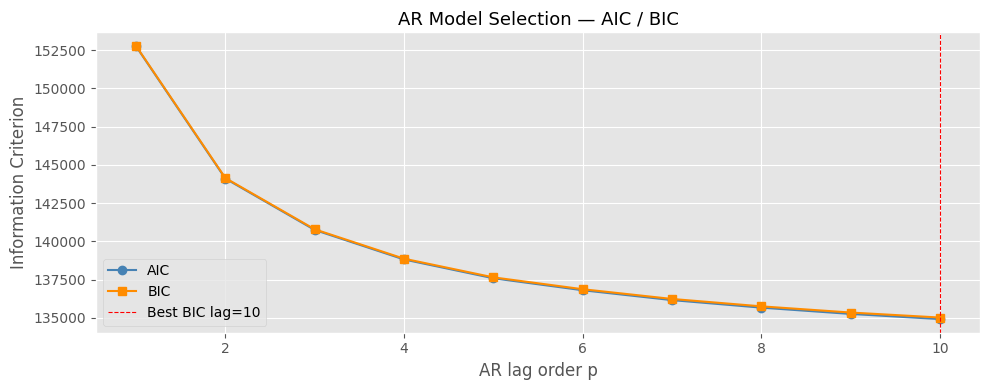

In [11]:
aic_vals, bic_vals = [], []
for p in range(1, AR_MAX_P + 1):
    try:
        m = AutoReg(series.values, lags=p, trend='c').fit()
        aic_vals.append(m.aic); bic_vals.append(m.bic)
    except Exception:
        aic_vals.append(np.nan); bic_vals.append(np.nan)

best_p_aic = np.nanargmin(aic_vals) + 1
best_p_bic = np.nanargmin(bic_vals) + 1
print(f"Best AR order by AIC: {best_p_aic}")
print(f"Best AR order by BIC: {best_p_bic}")

best_p = best_p_bic  # BIC is more parsimonious
ar_model = AutoReg(series.values, lags=best_p, trend='c').fit()
print(f"\nAR({best_p}) coefficients (lag 1 to {best_p}):")
for i, c in enumerate(ar_model.params[1:best_p+1], 1):
    print(f"  φ_{i} = {c:.6f}")
print(f"  Intercept = {ar_model.params[0]:.4f}")

if len(ar_model.params) > 1 and abs(ar_model.params[1]) > 0.01:
    sign = ar_model.params[1]
    print(f"\n  AR(1) coeff = {sign:.4f} → "
          f"{'mean-reverting tendency ✅' if sign < 0 else 'persistence / trending ⚠'}")

fig, ax = plt.subplots(figsize=(10, 4))
lags_range = range(1, AR_MAX_P + 1)
ax.plot(lags_range, aic_vals, 'o-', color='steelblue', label='AIC')
ax.plot(lags_range, bic_vals, 's-', color='darkorange', label='BIC')
ax.axvline(best_p_bic, color='red', linestyle='--', linewidth=0.8,
           label=f'Best BIC lag={best_p_bic}')
ax.set_xlabel('AR lag order p'); ax.set_ylabel('Information Criterion')
ax.set_title('AR Model Selection — AIC / BIC')
ax.legend(); plt.tight_layout(); plt.show()

## 11. Statistical Summary & Strategy Implications

In [12]:
rows = [
    ("ADF (levels)",        f"p={adf_p_level:.4f}",
     "Stationary ✅" if adf_p_level < 0.05 else "Unit root ❌"),
    ("KPSS (levels)",       f"p={kpss_p_level:.4f}",
     "Stationary ✅" if kpss_p_level > 0.05 else "Non-stationary ❌"),
    ("ADF (log-ret)",       f"p={adf_p_ret:.4f}",
     "Stationary ✅" if adf_p_ret < 0.05 else "Unit root ❌"),
    ("KPSS (log-ret)",      f"p={kpss_p_ret:.4f}",
     "Stationary ✅" if kpss_p_ret > 0.05 else "Non-stationary ❌"),
    ("Drift (OLS)",         f"slope_p={slope_pval:.4f}",
     "No drift ✅" if slope_pval >= 0.05 else f"Drift {'↑' if slope > 0 else '↓'} ⚠"),
    ("Hurst exponent",      f"H={H:.4f}",
     "Mean-reverting ✅" if H < 0.45 else ("Random walk" if H < 0.55 else "Trending ⚠")),
    ("AR(1) coefficient",   f"φ₁={ar_model.params[1] if best_p>=1 else np.nan:.4f}",
     "Mean-revert tendency ✅" if best_p >= 1 and ar_model.params[1] < 0 else "Persistent ⚠"),
    ("VR (k=2)",            f"VR={vr_results[0][1]:.4f}",
     "Mean-reverting ✅" if vr_results[0][1] < 0.95 else
     ("Random walk" if vr_results[0][1] < 1.05 else "Trending ⚠")),
]

summary = pd.DataFrame(rows, columns=['Test', 'Value', 'Verdict'])
print(summary.to_string(index=False))

n_good = sum(1 for _, _, v in rows if '✅' in v)
print(f"\n{'─'*55}")
print(f"  Strategy fitness: {n_good}/{len(rows)} indicators favour mean-reversion")
if n_good >= 5:
    print("  → STRONG candidate for mean-reversion / stat-arb strategy ✅")
elif n_good >= 3:
    print("  → MODERATE — consider risk controls, regime gating ⚠")
else:
    print("  → WEAK — series may be trending; reconsider approach ❌")

             Test          Value          Verdict
     ADF (levels)       p=0.9606      Unit root ❌
    KPSS (levels)       p=0.0100 Non-stationary ❌
    ADF (log-ret)       p=0.0000     Stationary ✅
   KPSS (log-ret)       p=0.0702     Stationary ✅
      Drift (OLS) slope_p=0.0000        Drift ↑ ⚠
   Hurst exponent       H=1.1921       Trending ⚠
AR(1) coefficient      φ₁=0.1039     Persistent ⚠
         VR (k=2)      VR=0.5013 Mean-reverting ✅

───────────────────────────────────────────────────────
  Strategy fitness: 3/8 indicators favour mean-reversion
  → MODERATE — consider risk controls, regime gating ⚠


## 12. Feature Engineering

In [13]:
feat = pd.DataFrame(index=series.index)
feat['series']     = series
feat['sma']        = sma(series, N_WINDOW)
feat['ema']        = ema(series, N_WINDOW)
feat['zscore']     = zscore(series, N_WINDOW)
feat['rsi']        = rsi(series, 14)
feat['bb_lo'], feat['bb_mid'], feat['bb_hi'] = bollinger(series, N_WINDOW, 2)
feat['macd_line'], feat['macd_sig'], feat['macd_hist'] = macd(series)
feat['momentum']   = momentum(series, 10)
feat.dropna(inplace=True)
print(feat.describe().round(4))

           series         sma         ema      zscore         rsi       bb_lo  \
count  29892.0000  29892.0000  29892.0000  29892.0000  29892.0000  29892.0000   
mean   11500.5547  11499.6041  11499.6040      0.4748     53.5015  11495.2720   
std      865.5897    865.5867    865.5867      0.9404      7.1899    865.3248   
min     9999.0000  10001.1500  10000.9590     -4.0037      8.3333   9997.9039   
25%    10751.5000  10750.1375  10749.9986      0.1563     50.4651  10746.6828   
50%    11500.5000  11500.0500  11500.4074      0.4802     52.8736  11495.0889   
75%    12249.1250  12248.2438  12248.3509      0.8356     56.0000  12244.6192   
max    13007.0000  12999.1250  12999.2591      4.1020     92.5926  12996.3680   

           bb_mid       bb_hi   macd_line    macd_sig   macd_hist    momentum  
count  29892.0000  29892.0000  29892.0000  29892.0000  29892.0000  29892.0000  
mean   11499.6041  11503.9361      0.7011      0.7011     -0.0001      1.0006  
std      865.5867    865.8509 

## 13. Strategy Dashboard

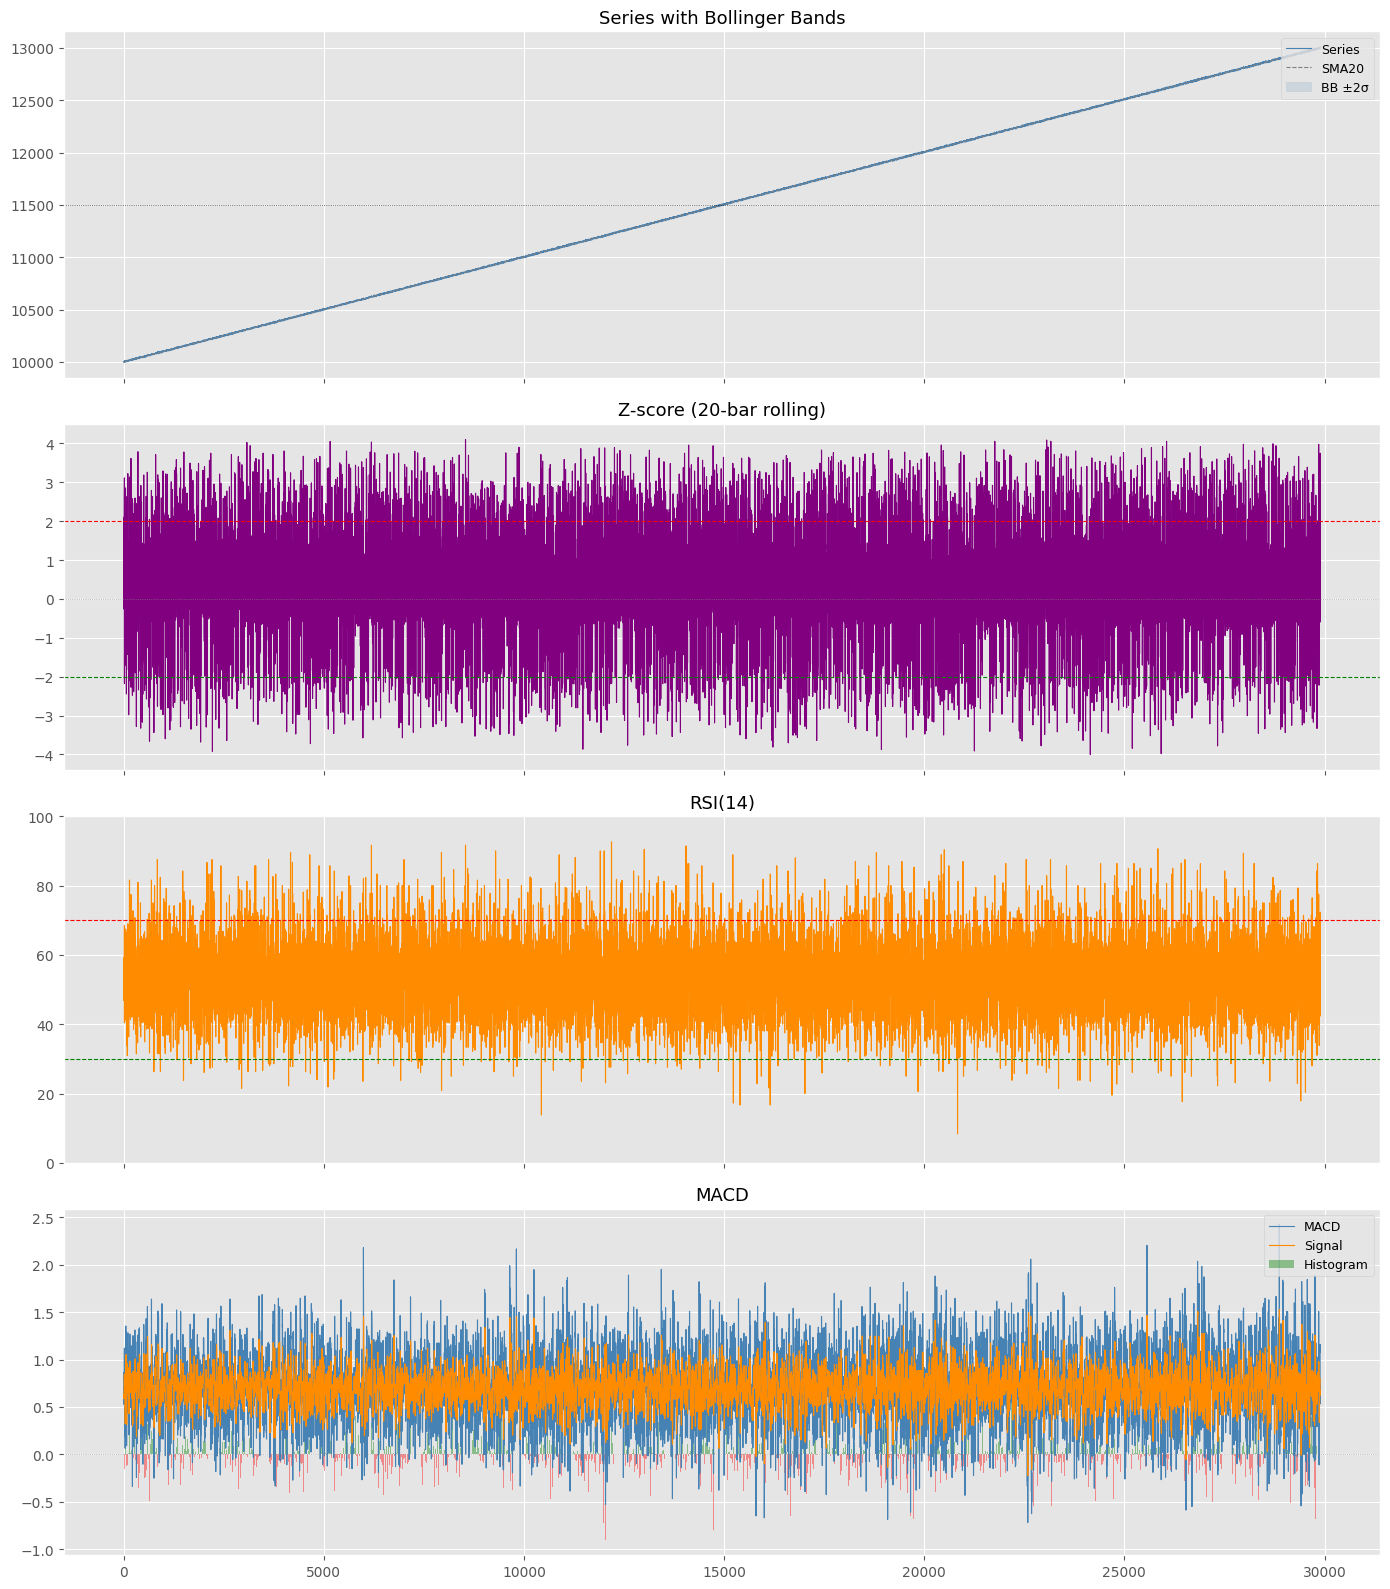

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

ax = axes[0]
ax.plot(feat['series'].values, color='steelblue', linewidth=0.8, label='Series')
ax.plot(feat['bb_mid'].values, color='gray', linestyle='--', linewidth=0.8, label=f'SMA{N_WINDOW}')
ax.fill_between(range(len(feat)), feat['bb_lo'].values, feat['bb_hi'].values,
                alpha=0.15, color='steelblue', label='BB ±2σ')
ax.axhline(feat['series'].mean(), color='black', linewidth=0.5, linestyle=':')
ax.set_title('Series with Bollinger Bands'); ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
ax.plot(feat['zscore'].values, color='purple', linewidth=0.8)
ax.axhline(2,  color='red',   linestyle='--', linewidth=0.8)
ax.axhline(-2, color='green', linestyle='--', linewidth=0.8)
ax.axhline(0,  color='gray',  linestyle=':',  linewidth=0.5)
ax.set_title(f'Z-score ({N_WINDOW}-bar rolling)')

ax = axes[2]
ax.plot(feat['rsi'].values, color='darkorange', linewidth=0.8)
ax.axhline(70, color='red',   linestyle='--', linewidth=0.8)
ax.axhline(30, color='green', linestyle='--', linewidth=0.8)
ax.set_ylim(0, 100); ax.set_title('RSI(14)')

ax = axes[3]
ax.plot(feat['macd_line'].values, color='steelblue',  linewidth=0.8, label='MACD')
ax.plot(feat['macd_sig'].values,  color='darkorange', linewidth=0.8, label='Signal')
colors = ['green' if v >= 0 else 'red' for v in feat['macd_hist'].values]
ax.bar(range(len(feat)), feat['macd_hist'].values, color=colors, alpha=0.4, label='Histogram')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
ax.set_title('MACD'); ax.legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.show()

## 14. Multi-Signal Alpha Score

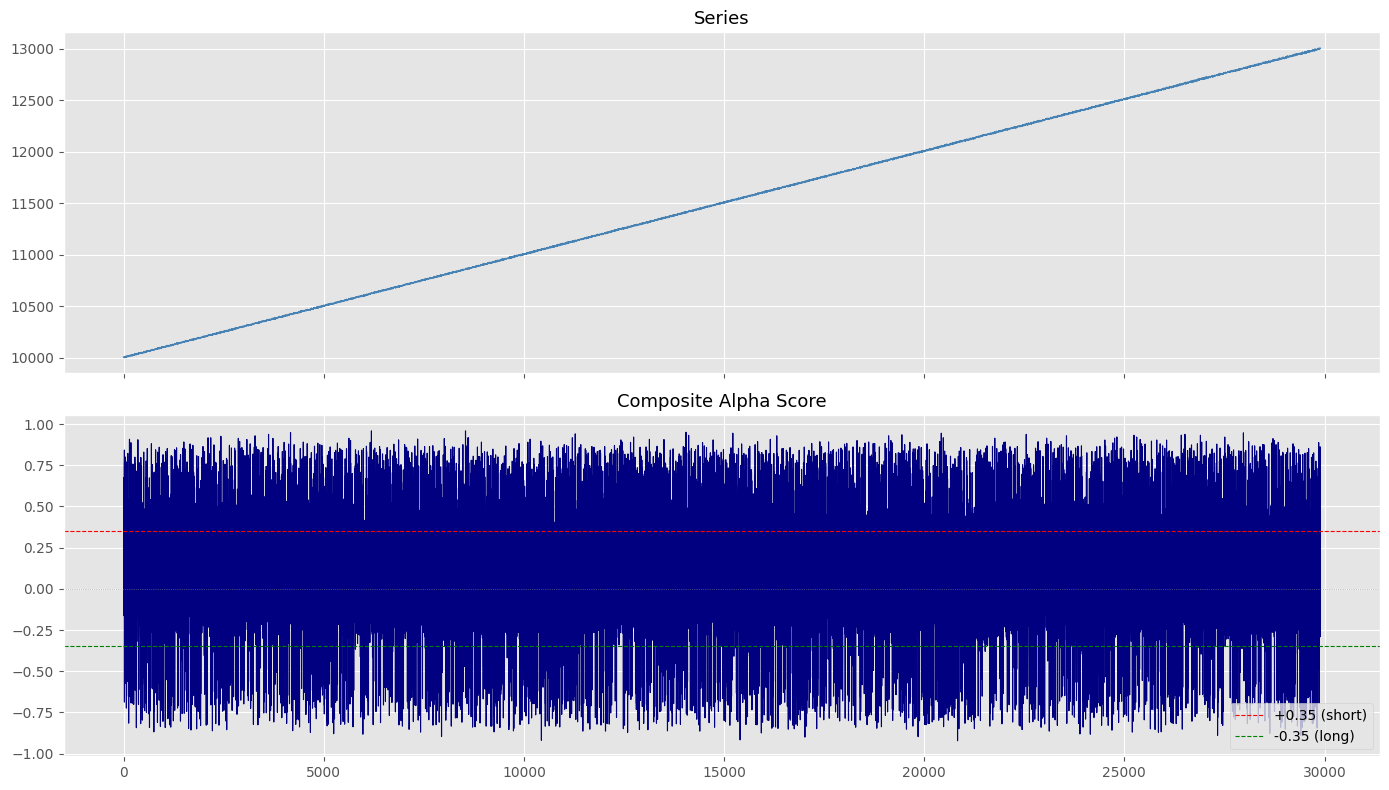

Short signals: 5918
Long  signals: 1655


In [15]:
# Positive composite → series expensive → short
feat['sig_zscore'] = feat['zscore'].clip(-3, 3) / 3
feat['sig_rsi']    = (feat['rsi'] - 50) / 50
feat['sig_bb']     = ((feat['series'] - feat['bb_mid']) /
                       (feat['bb_hi'] - feat['bb_mid']).replace(0, np.nan)).clip(-1, 1)
feat['sig_macd']   = np.sign(feat['macd_hist']).fillna(0)

feat['composite'] = sum(feat[k] * v for k, v in SIG_WEIGHTS.items())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(feat['series'].values, linewidth=0.8, color='steelblue')
axes[0].set_title('Series')
axes[1].plot(feat['composite'].values, linewidth=0.8, color='navy')
axes[1].axhline( ENTRY_THRESHOLD, color='red',   linestyle='--', linewidth=0.8,
                 label=f'+{ENTRY_THRESHOLD} (short)')
axes[1].axhline(-ENTRY_THRESHOLD, color='green', linestyle='--', linewidth=0.8,
                 label=f'-{ENTRY_THRESHOLD} (long)')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axes[1].set_title('Composite Alpha Score')
axes[1].legend(); plt.tight_layout(); plt.show()

print(f"Short signals: {(feat['composite'] >  ENTRY_THRESHOLD).sum()}")
print(f"Long  signals: {(feat['composite'] < -ENTRY_THRESHOLD).sum()}")

## 15. Signal Quality Analysis

In [16]:
FWDS = [1, 5, 20]
rows_sq = []
for sig_col in SIG_WEIGHTS:
    direction = np.sign(feat[sig_col])
    for fwd in FWDS:
        fwd_ret     = feat['series'].shift(-fwd) - feat['series']
        aligned_ret = (direction * (-fwd_ret)).dropna()
        hit_rate    = (aligned_ret > 0).mean()
        rows_sq.append({'signal': sig_col, 'horizon': fwd,
                        'hit_rate': f'{hit_rate:.1%}',
                        'avg_pnl': f'{aligned_ret.mean():.4f}'})
print(pd.DataFrame(rows_sq).to_string(index=False))

    signal  horizon hit_rate avg_pnl
sig_zscore        1    42.1%  0.8966
sig_zscore        5    43.0%  0.6594
sig_zscore       20    28.2% -0.3171
   sig_rsi        1    36.7%  0.7554
   sig_rsi        5    38.8%  0.5452
   sig_rsi       20    26.5% -0.3503
    sig_bb        1    42.1%  0.8966
    sig_bb        5    43.0%  0.6594
    sig_bb       20    28.2% -0.3171
  sig_macd        1    44.5%  0.8807
  sig_macd        5    56.5%  0.9068
  sig_macd       20    56.1%  0.9248


## 16. Backtest Simulation

Total PnL:       -5835.00
Sharpe:            -2.843
Max Drawdown:    -5891.50
Avg |pos|:           2.04


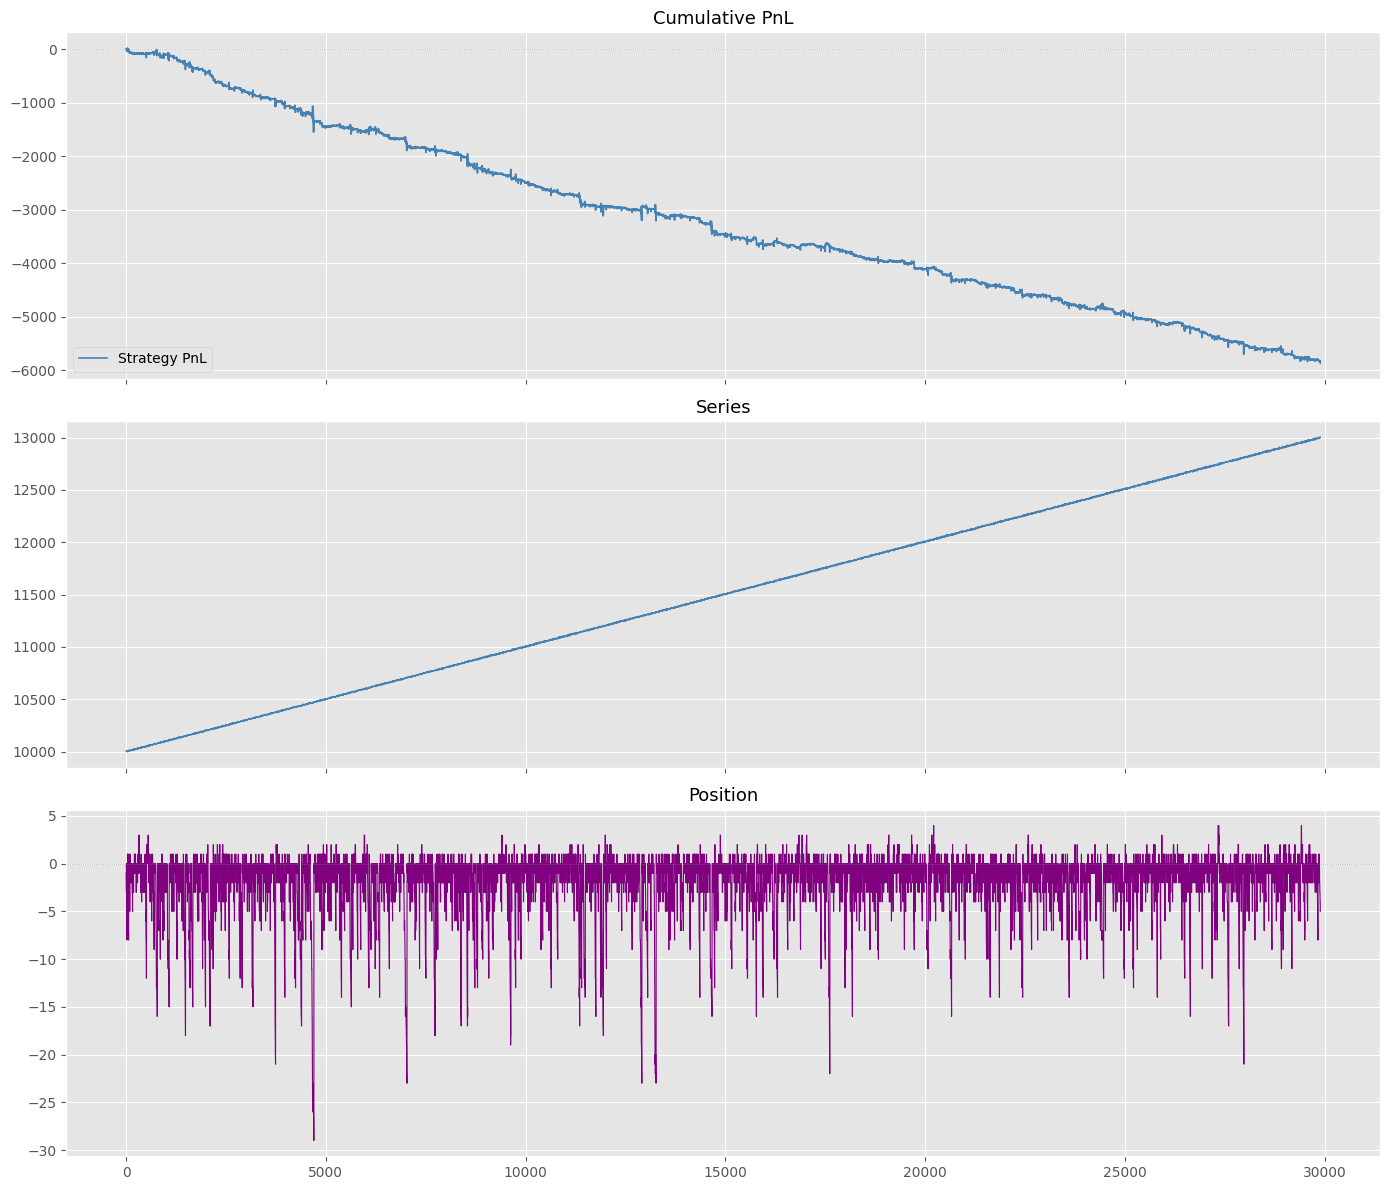

In [17]:
positions = []
pos = 0
for _, row in feat.iterrows():
    sc = row['composite']
    if   sc >  ENTRY_THRESHOLD and pos > -POS_LIMIT: pos -= UNIT_SIZE
    elif sc < -ENTRY_THRESHOLD and pos <  POS_LIMIT: pos += UNIT_SIZE
    elif abs(sc) < EXIT_THRESH: pos = 0
    positions.append(pos)

positions  = np.array(positions)
series_arr = feat['series'].values
pnl        = np.diff(series_arr, prepend=series_arr[0]) * positions
cum_pnl    = np.cumsum(pnl)
sharpe     = pnl.mean() / (pnl.std() + 1e-9) * np.sqrt(len(pnl))
max_dd     = (cum_pnl - np.maximum.accumulate(cum_pnl)).min()

print(f"Total PnL:   {cum_pnl[-1]:>12.2f}")
print(f"Sharpe:      {sharpe:>12.3f}")
print(f"Max Drawdown:{max_dd:>12.2f}")
print(f"Avg |pos|:   {np.abs(positions).mean():>12.2f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].plot(cum_pnl, color='steelblue', linewidth=1.2, label='Strategy PnL')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axes[0].set_title('Cumulative PnL'); axes[0].legend()
axes[1].plot(series_arr, color='steelblue', linewidth=0.8)
axes[1].set_title('Series')
axes[2].plot(positions, color='purple', linewidth=0.8)
axes[2].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axes[2].set_title('Position')
plt.tight_layout(); plt.show()

## 17. Inventory-Aware Backtest

Inventory-aware | PnL: -5835.00  Sharpe: -2.843  MaxDD: -5891.50
Baseline        | PnL: -5835.00  Sharpe: -2.843  MaxDD: -5891.50


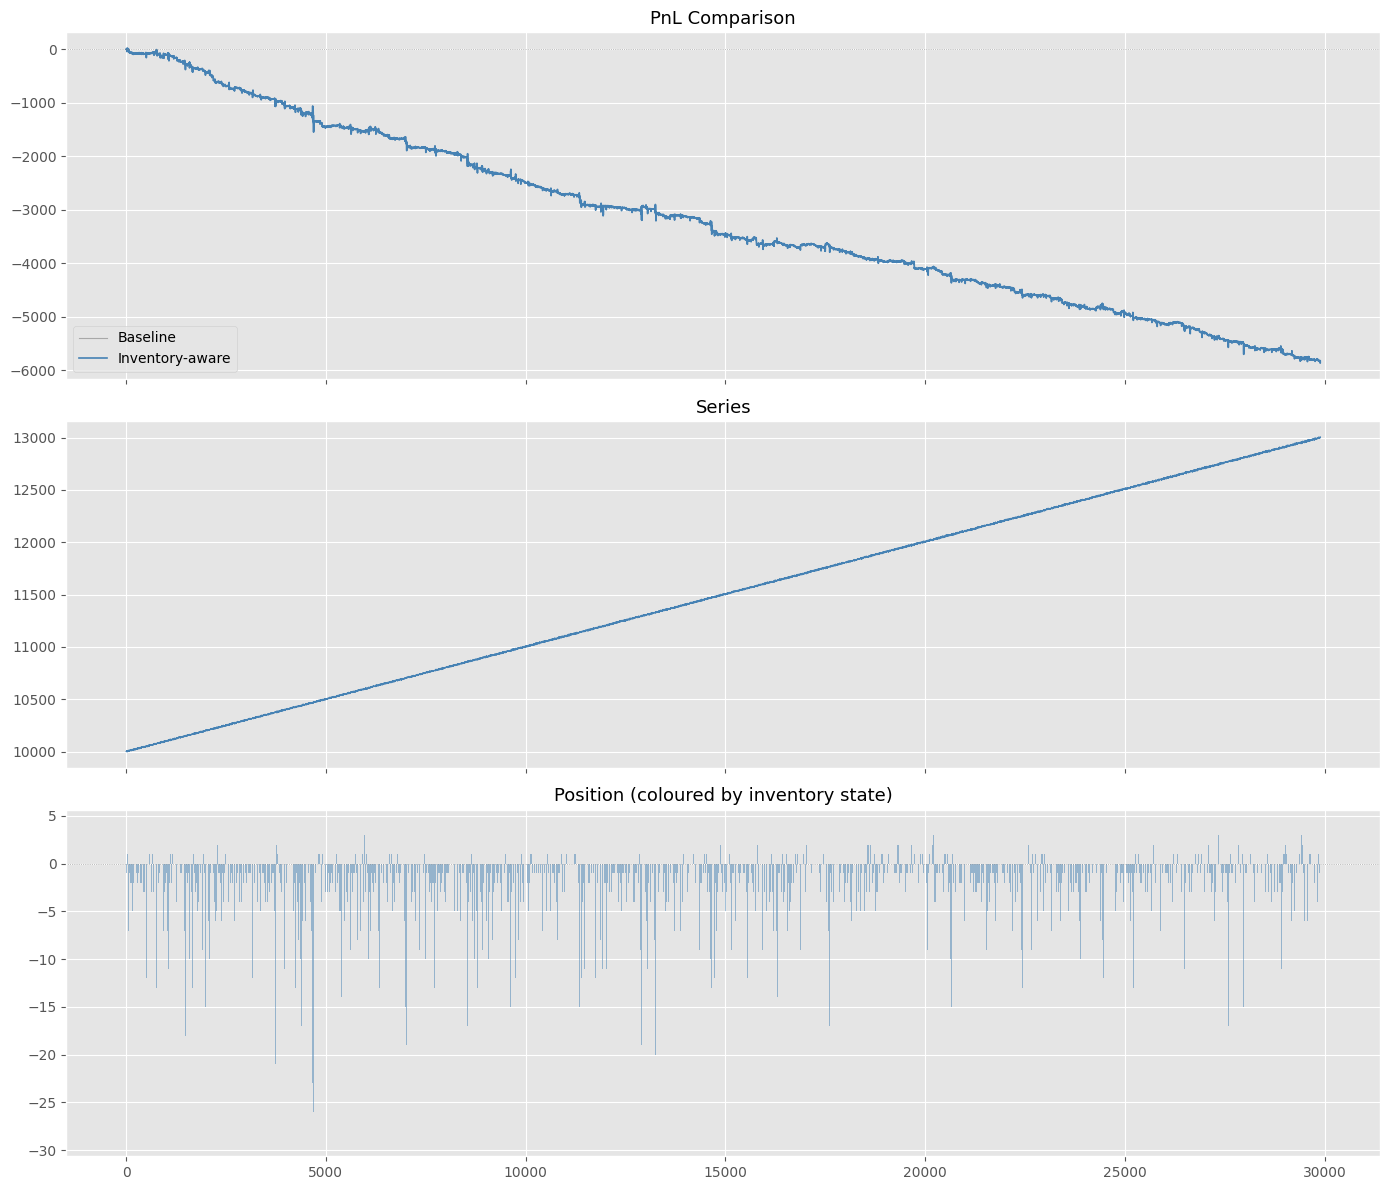

  Flat       | n=29892  PnL= -5835.0  Sharpe=-2.84
  Light      | n=    0  PnL=     0.0  Sharpe=nan
  Moderate   | n=    0  PnL=     0.0  Sharpe=nan
  Heavy      | n=    0  PnL=     0.0  Sharpe=nan


In [18]:
STATE_BINS  = [0, 0.3, 0.6, 0.85, 1.01]
STATE_NAMES = ['Flat', 'Light', 'Moderate', 'Heavy']

def inv_state(pos): return STATE_NAMES[np.searchsorted(STATE_BINS, abs(pos)/POS_LIMIT, side='right') - 1]

pos2, positions2, entry_bar, entry_price = 0, [], None, None
pnl2_arr, states = [], []

for bar, (idx, row) in enumerate(feat.iterrows()):
    sc    = row['composite']
    price = row['series']
    abs_pos = abs(pos2)

    # MTM exit
    if entry_price is not None:
        mtm = (price - entry_price) * pos2
        if mtm < MTM_PAIN:
            pos2 = 0; entry_price = None; entry_bar = None

    # Stale position urgency
    urgency = 1.0
    if entry_bar is not None and (bar - entry_bar) > STALE_BARS:
        urgency = 1.5 + (bar - entry_bar - STALE_BARS) / STALE_BARS

    # Position limit scaling
    size_mul = max(0.0, 1.0 - (abs_pos - SOFT_LIMIT) / (POS_LIMIT - SOFT_LIMIT)) if abs_pos > SOFT_LIMIT else 1.0
    adj_unit = max(1, int(UNIT_SIZE * size_mul * urgency))

    if sc >  ENTRY_THRESHOLD and pos2 > -POS_LIMIT:
        pos2 -= adj_unit
        if entry_price is None: entry_price, entry_bar = price, bar
    elif sc < -ENTRY_THRESHOLD and pos2 <  POS_LIMIT:
        pos2 += adj_unit
        if entry_price is None: entry_price, entry_bar = price, bar
    elif abs(sc) < EXIT_THRESH:
        pos2 = 0; entry_price = None; entry_bar = None

    pos2 = np.clip(pos2, -POS_LIMIT, POS_LIMIT)
    positions2.append(pos2)
    states.append(inv_state(pos2))

positions2 = np.array(positions2)
pnl2 = np.diff(series_arr, prepend=series_arr[0]) * positions2
cum_pnl2 = np.cumsum(pnl2)
sharpe2  = pnl2.mean() / (pnl2.std() + 1e-9) * np.sqrt(len(pnl2))
max_dd2  = (cum_pnl2 - np.maximum.accumulate(cum_pnl2)).min()

print(f"Inventory-aware | PnL: {cum_pnl2[-1]:.2f}  Sharpe: {sharpe2:.3f}  MaxDD: {max_dd2:.2f}")
print(f"Baseline        | PnL: {cum_pnl[-1]:.2f}  Sharpe: {sharpe:.3f}  MaxDD: {max_dd:.2f}")

# ── Plot ──
state_colors = {'Flat': 'steelblue', 'Light': 'green', 'Moderate': 'orange', 'Heavy': 'red'}
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].plot(cum_pnl,  color='gray',      linewidth=0.8, label='Baseline', alpha=0.6)
axes[0].plot(cum_pnl2, color='steelblue', linewidth=1.2, label='Inventory-aware')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axes[0].set_title('PnL Comparison'); axes[0].legend()
axes[1].plot(series_arr, color='steelblue', linewidth=0.8)
axes[1].set_title('Series')
for i, (p, st) in enumerate(zip(positions2, states)):
    axes[2].bar(i, p, color=state_colors.get(st, 'gray'), alpha=0.5, width=1)
axes[2].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axes[2].set_title('Position (coloured by inventory state)')
plt.tight_layout(); plt.show()

# ── PnL by state ──
pnl2_s = pd.Series(pnl2)
for st in STATE_NAMES:
    mask = np.array(states) == st
    p = pnl2_s[mask]
    print(f"  {st:10s} | n={mask.sum():5d}  PnL={p.sum():8.1f}  "
          f"Sharpe={p.mean()/(p.std()+1e-9)*np.sqrt(max(1,mask.sum())):.2f}")

## 18. Rolling Sharpe

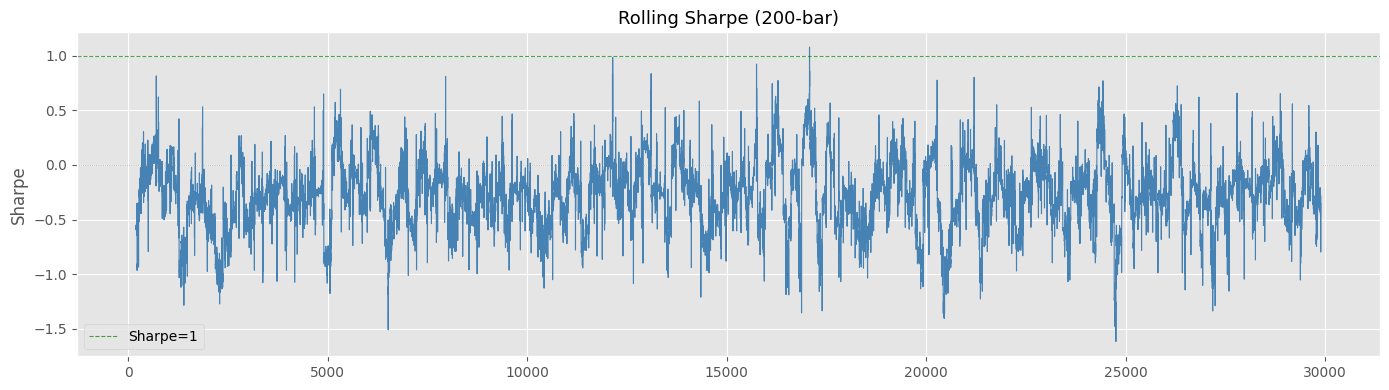

In [19]:
pnl_s = pd.Series(pnl2)
rolling_sharpe = (pnl_s.rolling(ROLL_W).mean() /
                  (pnl_s.rolling(ROLL_W).std() + 1e-9)) * np.sqrt(ROLL_W)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_sharpe.values, color='steelblue', linewidth=0.8)
ax.axhline(0, color='gray',  linestyle=':', linewidth=0.5)
ax.axhline(1, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='Sharpe=1')
ax.set_title(f'Rolling Sharpe ({ROLL_W}-bar)'); ax.set_ylabel('Sharpe')
ax.legend(); plt.tight_layout(); plt.show()

## 19. Parameter Sensitivity — Entry Threshold Sweep

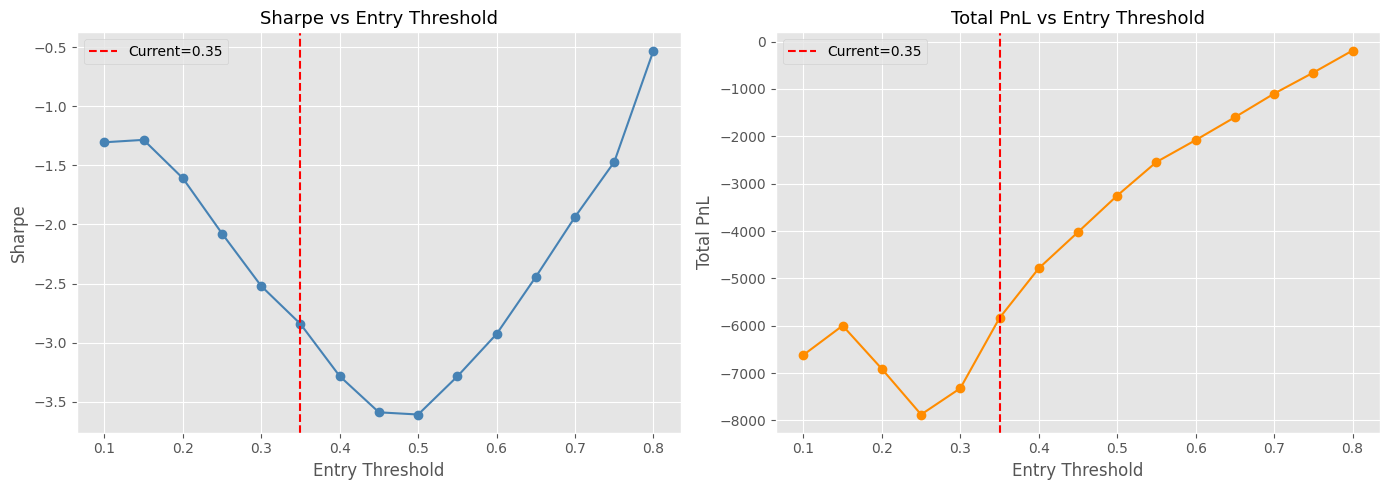

Best threshold by Sharpe: 0.80 (Sharpe=-0.527)
Best threshold by PnL:    0.80 (PnL=-188.50)


In [20]:
thresholds = np.arange(0.10, 0.81, 0.05)
sharpe_vals, pnl_vals = [], []

for thresh in thresholds:
    p_t, p_arr = 0, []
    for _, row in feat.iterrows():
        sc = row['composite']
        if   sc >  thresh and p_t > -POS_LIMIT: p_t -= UNIT_SIZE
        elif sc < -thresh and p_t <  POS_LIMIT: p_t += UNIT_SIZE
        elif abs(sc) < EXIT_THRESH: p_t = 0
        p_arr.append(p_t)
    pnl_t = np.diff(feat['series'].values, prepend=feat['series'].values[0]) * np.array(p_arr)
    sharpe_vals.append(pnl_t.mean() / (pnl_t.std() + 1e-9) * np.sqrt(len(pnl_t)))
    pnl_vals.append(pnl_t.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, sharpe_vals, 'o-', color='steelblue')
axes[0].axvline(ENTRY_THRESHOLD, color='red', linestyle='--',
                label=f'Current={ENTRY_THRESHOLD}')
axes[0].set_xlabel('Entry Threshold'); axes[0].set_ylabel('Sharpe')
axes[0].set_title('Sharpe vs Entry Threshold'); axes[0].legend()
axes[1].plot(thresholds, pnl_vals, 'o-', color='darkorange')
axes[1].axvline(ENTRY_THRESHOLD, color='red', linestyle='--',
                label=f'Current={ENTRY_THRESHOLD}')
axes[1].set_xlabel('Entry Threshold'); axes[1].set_ylabel('Total PnL')
axes[1].set_title('Total PnL vs Entry Threshold'); axes[1].legend()
plt.tight_layout(); plt.show()

best_thresh_sharpe = thresholds[np.argmax(sharpe_vals)]
best_thresh_pnl    = thresholds[np.argmax(pnl_vals)]
print(f"Best threshold by Sharpe: {best_thresh_sharpe:.2f} (Sharpe={max(sharpe_vals):.3f})")
print(f"Best threshold by PnL:    {best_thresh_pnl:.2f} (PnL={max(pnl_vals):.2f})")

## 21. Order Book Analysis

### What this measures

The **limit order book (LOB)** shows the full picture of supply and demand at any instant:
- **Bid side:** buyers willing to buy at each price level (L1 = best bid, L2, L3)
- **Ask side:** sellers willing to sell at each price level (L1 = best ask, L2, L3)

**Total depth** = sum of volume across all 3 bid (or ask) levels — a measure of market liquidity.

**Book imbalance:**
$$I_t = \frac{D^{bid}_t - D^{ask}_t}{D^{bid}_t + D^{ask}_t} \in [-1,\, +1]$$

- I → +1: heavy buying pressure → price likely to move up
- I → −1: heavy selling pressure → price likely to move down
- I ≈ 0: balanced book

### Interpretation

| Observation | Implication |
|---|---|
| High sustained bid depth | Buyers dominating — directional bias to upside |
| High sustained ask depth | Sellers dominating — directional bias to downside |
| Imbalance strongly predicts next-bar return | Imbalance is a viable real-time signal |
| Imbalance near zero on average | Balanced market — no persistent bias |
| Depth dries up during large moves | Thin liquidity causes outsized slippage — widen your spread |


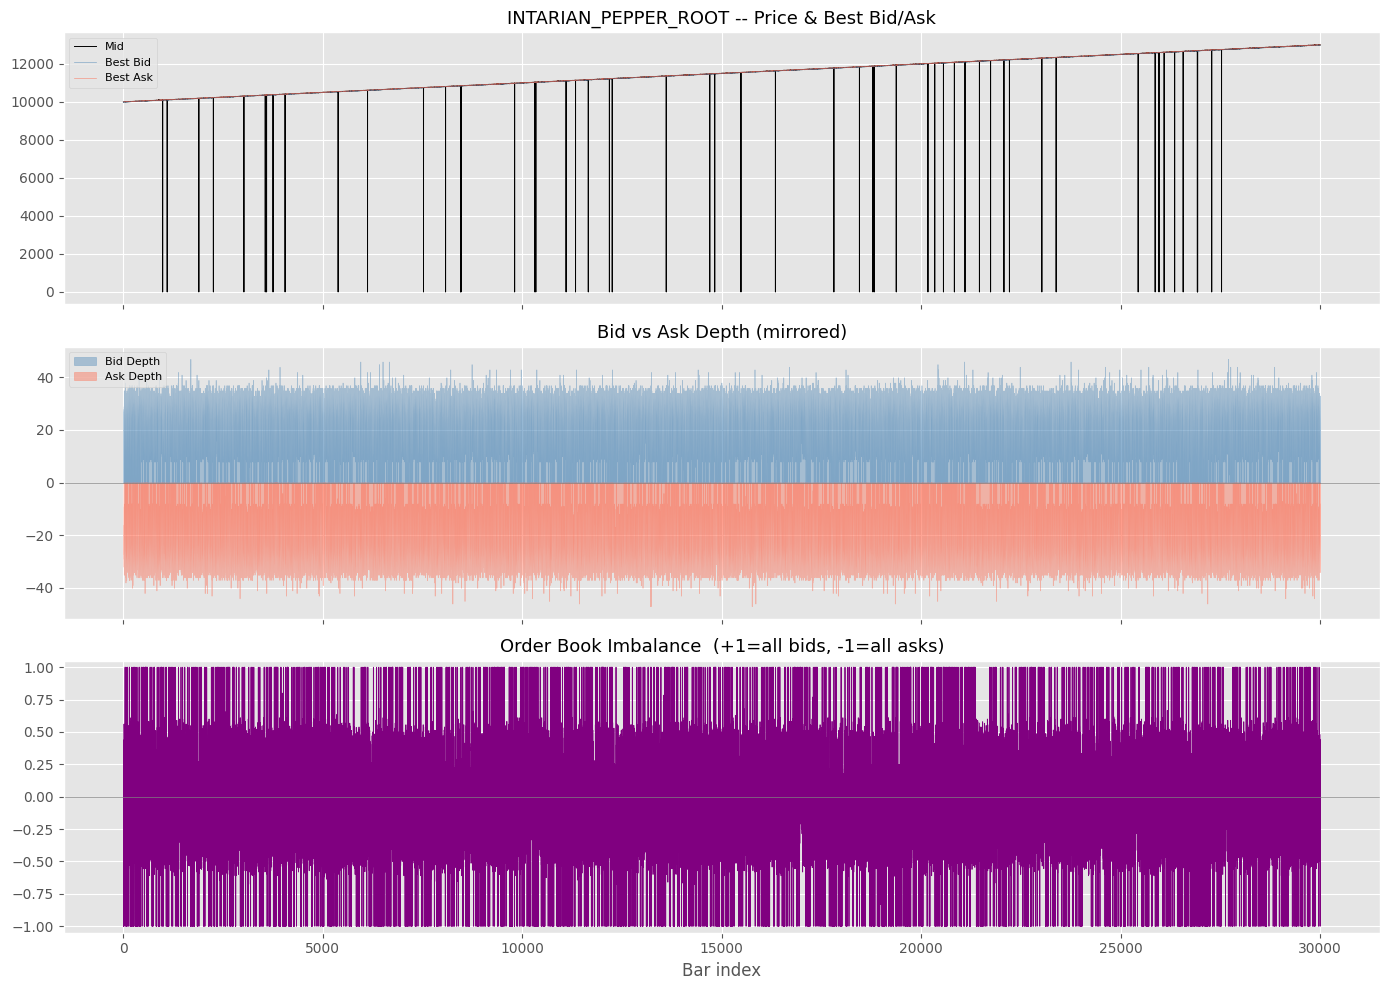

Mean imbalance : -0.0031
Imbalance std  : 0.3775
Mean bid depth : 24.1
Mean ask depth : 24.2


In [21]:
# Order Book Analysis
ob = prices[prices['product'] == PRODUCT].copy()
ob = ob.sort_values(['day','timestamp']).reset_index(drop=True)

for side, cols in [('bid', ['bid_volume_1','bid_volume_2','bid_volume_3']),
                    ('ask', ['ask_volume_1','ask_volume_2','ask_volume_3'])]:
    ob[f'{side}_depth'] = ob[cols].fillna(0).sum(axis=1)

tot = ob['bid_depth'] + ob['ask_depth']
ob['imbalance'] = (ob['bid_depth'] - ob['ask_depth']) / tot.replace(0, np.nan)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ob.index, ob['mid_price'], color='black', linewidth=0.7, label='Mid')
axes[0].plot(ob.index, ob['bid_price_1'], color='steelblue', linewidth=0.5, alpha=0.6, label='Best Bid')
axes[0].plot(ob.index, ob['ask_price_1'], color='tomato', linewidth=0.5, alpha=0.6, label='Best Ask')
axes[0].set_title(f'{PRODUCT} -- Price & Best Bid/Ask'); axes[0].legend(fontsize=8)

axes[1].fill_between(ob.index, ob['bid_depth'], alpha=0.4, color='steelblue', label='Bid Depth')
axes[1].fill_between(ob.index, -ob['ask_depth'], alpha=0.4, color='tomato', label='Ask Depth')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title('Bid vs Ask Depth (mirrored)'); axes[1].legend(fontsize=8)

axes[2].plot(ob.index, ob['imbalance'], color='purple', linewidth=0.6)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_ylim(-1.05, 1.05)
axes[2].set_title('Order Book Imbalance  (+1=all bids, -1=all asks)')
axes[2].set_xlabel('Bar index')

plt.tight_layout(); plt.show()

print(f'Mean imbalance : {ob["imbalance"].mean():.4f}')
print(f'Imbalance std  : {ob["imbalance"].std():.4f}')
print(f'Mean bid depth : {ob["bid_depth"].mean():.1f}')
print(f'Mean ask depth : {ob["ask_depth"].mean():.1f}')


## 22. Spread Analysis

### What this measures

The **bid-ask spread** = ask_price_1 − bid_price_1 is the cost of an immediate round-trip trade. It is the minimum profit your strategy must earn per trade to be viable.

$$\text{Spread}_t = p^{ask}_t - p^{bid}_t$$

A market-maker earns the spread on each completed trade; a market-taker pays it.

### Interpretation

| Observation | Implication |
|---|---|
| Spread is constant (always 1 or 2 ticks) | Market is well-mechanised — easy to model entry/exit costs |
| Spread widens during volatile periods | Liquidity providers pulling back — reduce position size or pause |
| High correlation between spread and \|fwd return\| | Spread is a useful volatility proxy / risk signal |
| Spread much larger than your expected alpha | Strategy not viable at current price impact — need wider signals |
| Wide spread fraction is high | Market is frequently illiquid — factor in adverse-fill risk |

> **Rule of thumb:** Your signal's expected PnL per bar must be comfortably greater than half the spread for a taker strategy to be profitable.


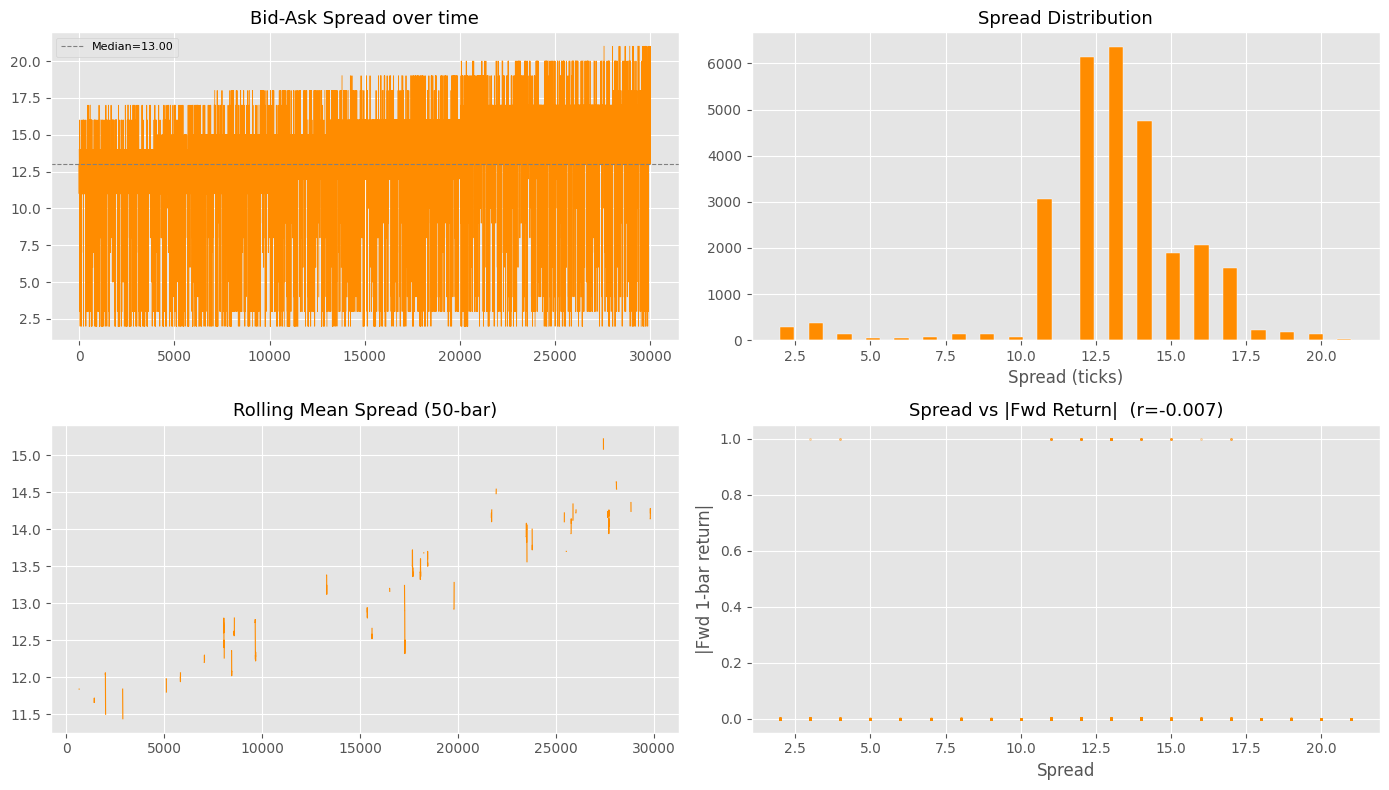

Spread  mean=13.047  median=13.000
Spread  min =2.000   max=21.000
Fraction of bars with spread > 2x median: 0.0%


In [22]:
# Spread Analysis
ob['spread'] = ob['ask_price_1'] - ob['bid_price_1']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

med_sp = ob['spread'].median()
axes[0,0].plot(ob.index, ob['spread'], color='darkorange', linewidth=0.6)
axes[0,0].axhline(med_sp, color='gray', linestyle='--', linewidth=0.8,
                   label=f'Median={med_sp:.2f}')
axes[0,0].set_title('Bid-Ask Spread over time'); axes[0,0].legend(fontsize=8)

axes[0,1].hist(ob['spread'].dropna(), bins=40, color='darkorange',
               edgecolor='white', linewidth=0.3)
axes[0,1].set_title('Spread Distribution'); axes[0,1].set_xlabel('Spread (ticks)')

roll_spread = ob['spread'].rolling(50).mean()
axes[1,0].plot(ob.index, roll_spread, color='darkorange', linewidth=0.8)
axes[1,0].set_title('Rolling Mean Spread (50-bar)')

fwd_abs_ret = ob['mid_price'].pct_change().shift(-1).abs()
corr = ob['spread'].corr(fwd_abs_ret)
axes[1,1].scatter(ob['spread'], fwd_abs_ret, s=2, alpha=0.3, color='darkorange')
axes[1,1].set_xlabel('Spread'); axes[1,1].set_ylabel('|Fwd 1-bar return|')
axes[1,1].set_title(f'Spread vs |Fwd Return|  (r={corr:.3f})')

plt.tight_layout(); plt.show()

print(f'Spread  mean={ob["spread"].mean():.3f}  median={ob["spread"].median():.3f}')
print(f'Spread  min ={ob["spread"].min():.3f}   max={ob["spread"].max():.3f}')
pct_wide = (ob['spread'] > ob['spread'].median() * 2).mean() * 100
print(f'Fraction of bars with spread > 2x median: {pct_wide:.1f}%')


## 22b. Roll Spread Estimator & Effective Spread

### What this measures

**Roll's (1984) implicit spread estimator** infers the effective cost of trading from the *serial covariance* of price changes — no trade-direction flags needed:

$$C_{\text{Roll}} = 2\sqrt{\max\!\left(0,\,-\operatorname{Cov}(\Delta p_t,\,\Delta p_{t-1})\right)}$$

**Why it works:** If each trade alternates between hitting the bid and lifting the ask (bid-ask bounce), successive price changes will be *negatively* correlated. The magnitude of that negative serial covariance equals the squared half-spread.

| Comparison | Interpretation |
|---|---|
| Roll ≈ Quoted | Spread is mechanical — no adverse-selection premium |
| Roll < Quoted | Part of spread is inventory/risk premium beyond transaction cost |
| Roll > Quoted | Unusual — may indicate mis-quote events or stale prices |

**Adverse-selection fraction** = Roll / Quoted — the share of the spread attributable to informed trading.

In [ ]:
# Roll Spread Estimator & Effective Spread
#
# Problem: ob spans 3 days. diff() at the first bar of each new day computes
#   P(start of day N) − P(end of day N-1)  →  overnight price jump
# This spurious large return biases the serial covariance.
#
# Three methods compared to handle boundary NaN / contamination:
#   1. dropna (mask)  — remove boundary diffs entirely                [BEST]
#   2. fill_last      — replace boundary diff with 0 (no overnight move assumed)
#   3. interpolate    — linearly smooth returns around the boundary

dp_raw        = ob['mid_price'].diff()
boundary_mask = ob['day'].diff().fillna(0) != 0  # True at first bar of each new day

# ── Method 1: dropna (mask + remove) ────────────────────────────────────────
# Remove boundary diffs: only within-day returns used for serial covariance
dp_m1         = dp_raw.where(~boundary_mask)        # set boundary to NaN
dp_m1_arr     = dp_m1.dropna().values
cov_m1        = np.cov(dp_m1_arr[1:], dp_m1_arr[:-1], ddof=1)[0, 1]
roll_m1       = 2 * np.sqrt(max(0.0, -cov_m1))

# ── Method 2: fill_last (boundary return = 0) ───────────────────────────────
# Assumes price "stands still" overnight: last price of day N = opening price of day N+1
# Implemented by zeroing the boundary diff (not forward-filling price)
dp_m2         = dp_raw.copy()
dp_m2[boundary_mask] = 0                            # overnight move → 0
dp_m2_arr     = dp_m2.dropna().values
cov_m2        = np.cov(dp_m2_arr[1:], dp_m2_arr[:-1], ddof=1)[0, 1]
roll_m2       = 2 * np.sqrt(max(0.0, -cov_m2))

# ── Method 3: linear interpolation ──────────────────────────────────────────
# Smooth the price series linearly across the boundary gap, then diff
# Effectively smears the overnight move over the two adjacent bars
price_interp  = ob['mid_price'].interpolate(method='index')
dp_m3         = price_interp.diff().where(~boundary_mask)  # still remove the boundary bar
dp_m3_arr     = dp_m3.dropna().values
cov_m3        = np.cov(dp_m3_arr[1:], dp_m3_arr[:-1], ddof=1)[0, 1]
roll_m3       = 2 * np.sqrt(max(0.0, -cov_m3))

# ── Comparison table ─────────────────────────────────────────────────────────
print(f"{'Method':<28} {'Cov(Δp_t,Δp_t-1)':>18} {'Roll spread':>13} {'n_pts':>7}")
print("─" * 70)
for label, cov, roll, arr in [
    ('1. dropna (mask)   [BEST]', cov_m1, roll_m1, dp_m1_arr),
    ('2. fill_last (0 return)',   cov_m2, roll_m2, dp_m2_arr),
    ('3. interpolate',            cov_m3, roll_m3, dp_m3_arr),
]:
    print(f"{label:<28} {cov:>18.6f} {roll:>13.4f} {len(arr):>7,}")

# ── Use best method ──────────────────────────────────────────────────────────
dp_arr     = dp_m1_arr   # dropna mask: no overnight contamination
cov_serial = cov_m1
roll_spread = roll_m1

quoted_mean = ob['spread'].mean()
quoted_med  = ob['spread'].median()
adv_frac    = roll_spread / quoted_mean if quoted_mean > 0 else float('nan')

print(f"\n{'Metric':<35} {'Value':>12}")
print("─" * 49)
print(f"{'Quoted spread — mean':<35} {quoted_mean:>12.4f}")
print(f"{'Quoted spread — median':<35} {quoted_med:>12.4f}")
print(f"{'Roll effective spread (best)':<35} {roll_spread:>12.4f}")
print(f"{'Serial cov(dp_t, dp_t-1)':<35} {cov_serial:>12.6f}")
print(f"{'Adverse-selection fraction':<35} {adv_frac:>12.2%}")

# Rolling Roll estimator (200-bar window, boundary-aware)
def rolling_roll(prices, day_col, w=200):
    out  = np.full(len(prices), np.nan)
    dp   = np.diff(prices)
    days = day_col.values
    bnd  = np.zeros(len(dp), dtype=bool)
    bnd[np.where(np.diff(days) != 0)] = True  # boundary positions in diff array
    for i in range(w, len(prices)):
        sl   = dp[i - w : i]
        bsl  = bnd[i - w : i]
        sl   = sl[~bsl]               # remove boundary diffs from window
        if len(sl) < w // 2: continue # too few points
        cov  = np.cov(sl[1:], sl[:-1], ddof=1)[0, 1]
        out[i] = 2 * np.sqrt(max(0.0, -cov))
    return out

roll_ts = rolling_roll(ob['mid_price'].values, ob['day'], w=200)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: rolling estimator comparison (all 3 methods — just for boundary bars)
axes[0].plot(ob.index, ob['spread'], color='darkorange', linewidth=0.5, alpha=0.6, label='Quoted')
axes[0].plot(ob.index, roll_ts,      color='steelblue',  linewidth=1.0,            label='Roll (dropna)')
axes[0].set_title('Quoted Spread vs Roll (boundary-clean)'); axes[0].legend(fontsize=8)

# Centre: bar chart of Roll estimates per method
labels_ = ['1. dropna\n(mask)', '2. fill_last\n(0 ret)', '3. interpolate']
vals_   = [roll_m1, roll_m2, roll_m3]
clrs_   = ['steelblue', 'sandybrown', 'mediumpurple']
bars_   = axes[1].bar(labels_, vals_, color=clrs_, edgecolor='white', width=0.5)
for b, v in zip(bars_, vals_):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].axhline(quoted_mean, color='darkorange', linestyle='--', linewidth=0.8, label='Quoted mean')
axes[1].set_title('Roll Estimate by NaN Method'); axes[1].legend(fontsize=8)

# Right: spread comparison bar
for ax, label, vals, colors in [(axes[2], 'Full comparison',
    ['Quoted\n(mean)', 'Quoted\n(med)', 'Roll\ndropna', 'Roll\nfill 0', 'Roll\ninterp'],
    ['darkorange','sandybrown','steelblue','indianred','mediumpurple'])]:
    all_vals = [quoted_mean, quoted_med, roll_m1, roll_m2, roll_m3]
    b2 = ax.bar(vals, all_vals, color=colors, edgecolor='white', width=0.5)
    for b, v in zip(b2, all_vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(label); ax.set_ylabel('Ticks')

plt.tight_layout(); plt.show()
print(
    f"\nBest method: dropna (mask)  | Roll/Quoted = {adv_frac:.1%} — " +
    ("high adverse-selection premium" if adv_frac > 0.7 else
     "moderate adverse selection"     if adv_frac > 0.4 else
     "low adverse selection — spread mostly mechanical")
)

## 22c. Spread Regime Analysis

### What this measures

Spread levels cluster into discrete **regimes** reflecting market conditions. We define four regimes via quantile thresholds:

| Regime | Condition | Market state |
|---|---|---|
| **Tight** | spread ≤ Q25 | High liquidity, low maker risk |
| **Normal** | Q25 < spread ≤ Q75 | Typical operating conditions |
| **Elevated** | Q75 < spread ≤ Q90 | Reduced liquidity / mild stress |
| **Wide** | spread > Q90 | Illiquid or high uncertainty |

**Regime persistence** (average run length per regime) indicates whether elevated costs are transient spikes or sustained episodes that would structurally erode strategy PnL.

In [ ]:
# Spread Regime Analysis

# Missing value handling strategy: implicit skipna=True (value_counts, aggregations) + fillna for categories
# Why: Regime classification is deterministic (no NaN if spread is not NaN), but we need to account for
#      missing regime category counts (e.g., if a regime never appears, value_counts() omits it)
# - apply(classify_regime): deterministic function, no new NaNs introduced
# - value_counts(): Ignores NaN automatically (skipna=True is default)
# - reindex(...).fillna(0): Fills missing regimes with 0 count (they were never observed)

q25, q75, q90 = ob['spread'].quantile([0.25, 0.75, 0.90]).values
regime_order  = ['Tight', 'Normal', 'Elevated', 'Wide']
regime_colors = {'Tight': '#2ecc71', 'Normal': '#3498db', 'Elevated': '#f39c12', 'Wide': '#e74c3c'}

def classify_regime(s):
    if s <= q25:   return 'Tight'
    elif s <= q75: return 'Normal'
    elif s <= q90: return 'Elevated'
    else:          return 'Wide'

ob['spread_regime'] = ob['spread'].apply(classify_regime)
freq     = ob['spread_regime'].value_counts().reindex(regime_order).fillna(0)  # fillna(0) for missing regimes
freq_pct = freq / len(ob) * 100

def avg_run_length(labels, regimes):
    runs = {r: [] for r in regimes}
    cur, cnt = None, 0
    for lbl in labels:
        if lbl == cur:
            cnt += 1
        else:
            if cur is not None:
                runs[cur].append(cnt)
            cur, cnt = lbl, 1
    if cur is not None:
        runs[cur].append(cnt)
    return {k: float(np.mean(v)) if v else 0.0 for k, v in runs.items()}  # Return 0.0 if regime never appeared

persistence = avg_run_length(ob['spread_regime'].values, regime_order)

print(f"Spread quantile thresholds — Q25: {q25:.1f}  Q75: {q75:.1f}  Q90: {q90:.1f}")
print(f"\n{'Regime':<12} {'Count':>8} {'Freq %':>8}  {'Avg run (bars)':>16}")
print("-" * 48)
for r in regime_order:
    print(f"{r:<12} {int(freq[r]):>8} {freq_pct[r]:>7.1f}%  {persistence[r]:>16.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

bars_f = axes[0].bar(regime_order, freq_pct,
                     color=[regime_colors[r] for r in regime_order], edgecolor='white')
for b, p in zip(bars_f, freq_pct):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Regime Frequency'); axes[0].set_ylabel('% of bars')

pers_vals = [persistence[r] for r in regime_order]
bars_p = axes[1].bar(regime_order, pers_vals,
                     color=[regime_colors[r] for r in regime_order], edgecolor='white')
for b, v in zip(bars_p, pers_vals):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.05,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Average Run Length (bars)'); axes[1].set_ylabel('Bars')

step = max(1, len(ob) // 4000)
smp  = ob.iloc[::step]
for r in regime_order:
    mask = smp['spread_regime'] == r
    axes[2].scatter(smp.index[mask], smp['spread'][mask],
                    color=regime_colors[r], s=1.5, label=r, alpha=0.8)
axes[2].set_title('Spread Coloured by Regime')
axes[2].set_xlabel('Bar index')
axes[2].legend(fontsize=7, markerscale=4)

plt.tight_layout(); plt.show()

## 22d. Intraday Spread Pattern & Strategy Breakeven

### What this measures

**Intraday spread pattern:** Market makers typically widen quotes at the start and end of each trading session, when inventory risk and information asymmetry are highest. This produces a **U-shaped spread curve** across the day.

**Spread autocorrelation (stickiness):** Measures whether a wide spread today predicts a wide spread in subsequent bars. High persistence means elevated execution costs are sustained — a structural drag rather than a transient spike.

**Breakeven edge analysis:** For a market-*taker* strategy to be profitable, the expected directional move over holding period $h$ must exceed the round-trip spread cost:

$$\mathbb{E}[|\Delta p_h|] > \text{spread}$$

| Metric | Formula | Interpretation |
|---|---|---|
| **Favorable fraction** | P(\|fwd move\| > spread) | % of bars where signal overcomes spread |
| **Edge ratio** | E[\|fwd move\|] / E[spread] | < 1 means execution drag dominates |

In [ ]:
# Intraday Spread Pattern & Strategy Breakeven
#
# Problem: intra['std'] has NaN for bins with 0 or 1 observation (sparse).
# fill_between requires non-NaN values → need to decide how to handle.
#
# Three methods compared for filling sparse std bins:
#   1. fillna(0)     — band collapses to zero width at sparse bins     [MISLEADING]
#   2. ffill         — use previous bin's std (forward-carry)          [ACCEPTABLE]
#   3. interpolate   — linear interpolation between non-sparse bins    [BEST]

N_BINS = 30

ob['ts_pct'] = ob.groupby('day')['timestamp'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9) * 100.0
)
ob['ts_bin'] = pd.cut(ob['ts_pct'], bins=N_BINS, labels=False)
intra     = ob.groupby('ts_bin')['spread'].agg(['mean', 'median', 'std'])
intra_mid = ob.groupby('ts_bin')['ts_pct'].mean()

n_sparse = intra['std'].isna().sum()
print(f"Sparse bins (std=NaN): {n_sparse} of {N_BINS}")

# ── Method 1: fillna(0) ──────────────────────────────────────────────────────
std_m1 = intra['std'].fillna(0)

# ── Method 2: ffill ──────────────────────────────────────────────────────────
std_m2 = intra['std'].ffill().bfill()   # bfill handles leading NaN

# ── Method 3: linear interpolation ──────────────────────────────────────────
std_m3 = intra['std'].interpolate(method='linear').ffill().bfill()  # edge fill

# ── Spread ACF (dropna — requires complete series) ───────────────────────────
spread_clean    = ob['spread'].dropna()
spread_acf_vals = [spread_clean.autocorr(lag=k) for k in range(1, 21)]

# ── Breakeven analysis (explicit .notna() masking) ───────────────────────────
horizons = [1, 5, 10, 20, 50]
rows = []
for h in horizons:
    fwd_abs  = ob['mid_price'].pct_change(h).shift(-h).abs() * ob['mid_price']
    sp_vals  = ob['spread']
    mask     = fwd_abs.notna() & sp_vals.notna()
    if mask.sum() == 0:
        continue
    fwd_m    = fwd_abs[mask].mean()
    sp_m     = sp_vals[mask].mean()
    fav_frac = (fwd_abs[mask] > sp_vals[mask]).mean()
    edge_r   = fwd_m / sp_m if sp_m > 0 else float('nan')
    rows.append({'horizon': h, 'mean_fwd_move': fwd_m, 'mean_spread': sp_m,
                 'favorable_frac': fav_frac, 'edge_ratio': edge_r})

be_df = pd.DataFrame(rows)
print("Breakeven Edge Analysis")
print(f"{'Horizon':>8} {'E[|move|]':>12} {'E[spread]':>12} {'Fav %':>8} {'Edge ratio':>12}")
print("─" * 56)
for _, r in be_df.iterrows():
    print(f"{int(r['horizon']):>8} {r['mean_fwd_move']:>12.4f} {r['mean_spread']:>12.4f} "
          f"{r['favorable_frac']:>7.1%} {r['edge_ratio']:>12.3f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# ── Top row: compare 3 std-fill methods ──────────────────────────────────────
method_cfgs = [
    (axes[0,0], std_m1, '#e74c3c', '1. fillna(0) — band collapses at sparse bins'),
    (axes[0,1], std_m3, '#2ecc71', '3. interpolate — smooth band  [BEST]'),
]
for ax, std_filled, clr, title in method_cfgs:
    ax.fill_between(intra_mid,
                    intra['mean'] - std_filled,
                    intra['mean'] + std_filled,
                    alpha=0.25, color=clr)
    ax.plot(intra_mid, intra['mean'],   color='darkorange', linewidth=1.5, label='Mean')
    ax.plot(intra_mid, intra['median'], color='navy',       linewidth=1.0, linestyle='--', label='Median')
    ax.set_title(title); ax.set_xlabel('% through day'); ax.set_ylabel('Spread (ticks)')
    ax.legend(fontsize=8)

# ffill shown as separate sub-panel
ax_ff = axes[1,0]
ax_ff.fill_between(intra_mid, intra['mean'] - std_m2, intra['mean'] + std_m2,
                   alpha=0.25, color='#f39c12')
ax_ff.plot(intra_mid, intra['mean'],   color='darkorange', linewidth=1.5, label='Mean')
ax_ff.plot(intra_mid, intra['median'], color='navy',       linewidth=1.0, linestyle='--', label='Median')
ax_ff.set_title('2. ffill — band persists at last known width')
ax_ff.set_xlabel('% through day'); ax_ff.set_ylabel('Spread (ticks)')
ax_ff.legend(fontsize=8)

# ── Bottom right: spread ACF ──────────────────────────────────────────────────
conf = 1.96 / np.sqrt(len(spread_clean))
axes[1,1].bar(range(1, 21), spread_acf_vals, color='darkorange', edgecolor='white')
axes[1,1].axhline(0,     color='gray', linewidth=0.8)
axes[1,1].axhline( conf, color='red',  linestyle='--', linewidth=0.8, label='95% CI')
axes[1,1].axhline(-conf, color='red',  linestyle='--', linewidth=0.8)
axes[1,1].set_title('Spread Autocorrelation (stickiness)')
axes[1,1].set_xlabel('Lag'); axes[1,1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# ── Breakeven chart (uses best intraday std = interpolate, separate figure) ───
if len(be_df) > 0:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2r = ax2.twinx()
    ax2.plot(be_df['horizon'], be_df['favorable_frac'] * 100,
             marker='o', color='steelblue', linewidth=1.5, label='Favorable %')
    ax2r.plot(be_df['horizon'], be_df['edge_ratio'],
              marker='s', color='darkorange', linewidth=1.5, linestyle='--', label='Edge ratio')
    ax2r.axhline(1.0, color='darkorange', linestyle=':', linewidth=0.8)
    ax2.set_title('Breakeven Edge by Holding Horizon')
    ax2.set_xlabel('Horizon (bars)'); ax2.set_ylabel('Favorable bars (%)', color='steelblue')
    ax2r.set_ylabel('Edge ratio (|move| / spread)', color='darkorange')
    l1, lb1 = ax2.get_legend_handles_labels()
    l2, lb2 = ax2r.get_legend_handles_labels()
    ax2.legend(l1 + l2, lb1 + lb2, fontsize=8)
    plt.tight_layout(); plt.show()

## 23. Volatility Analysis

### What this measures

**Volatility** quantifies the uncertainty / risk of the price process. Multiple estimators are used because each captures a different aspect:

**Realised volatility (rolling std of log returns)**
$$\sigma_t^{(W)} = \sqrt{\frac{1}{W}\sum_{i=0}^{W-1}(r_{t-i} - \bar{r})^2}$$
Scaled by √W to make it horizon-independent. Sensitive to outliers.

**Parkinson estimator** (uses bid/ask high-low range per bar)
$$\sigma^{Pk}_t = \sqrt{\frac{1}{4\ln 2} \left(\ln\frac{p^{ask}_t}{p^{bid}_t}\right)^2}$$
More efficient than close-to-close vol; exploits intrabar range information.

**Volatility clustering** (ACF of |log returns|)
Persistent autocorrelation in |returns| is the signature of **ARCH effects** — large moves tend to cluster in time (calm periods and storm periods).

**Ljung-Box on |returns|:** Low p-value confirms statistically significant clustering.

### Interpretation

| Observation | Implication |
|---|---|
| Rolling vol is stable | Position sizing can be fixed; signals are reliable |
| Rolling vol spikes and collapses | Regime-aware sizing needed — reduce size in high-vol periods |
| ACF of \|returns\| is significant | Clustering present — yesterday's vol predicts today's vol |
| Parkinson ≈ realised vol | Bid-ask spread is tight, no large intrabar spikes |
| High-vol regime fraction > 30% | Frequent instability — include a vol filter in your strategy |


In [ ]:
# Volatility Analysis
#
# Problem: log_ret = log(P_t / P_{t-1}) is computed across day boundaries.
# The overnight jump (last bar of day N → first bar of day N+1) is NOT intraday vol.
# It inflates rolling realized vol estimates whenever the window straddles a boundary.
#
# Three methods compared:
#   1. keep all         — current behaviour, overnight returns included
#   2. fill_last (ffill)— forward-fill prices across boundary → boundary return = 0
#   3. dropna (mask)    — NaN at boundary, rolling window skips it  [BEST]

boundary_mask = ob['day'].diff().fillna(0) != 0

# ── Method 1: keep all (current) ─────────────────────────────────────────────
ob['log_ret_m1'] = np.log(ob['mid_price'] / ob['mid_price'].shift(1))

# ── Method 2: fill_last (ffill prices → zero overnight return) ───────────────
price_ffill       = ob['mid_price'].ffill()   # no within-day gaps, but models "no gap overnight"
ob['log_ret_m2']  = np.log(price_ffill / price_ffill.shift(1))
ob.loc[boundary_mask, 'log_ret_m2'] = 0      # explicitly zero boundary return

# ── Method 3: dropna / mask ──────────────────────────────────────────────────
ob['log_ret_m3'] = np.log(ob['mid_price'] / ob['mid_price'].shift(1))
ob.loc[boundary_mask, 'log_ret_m3'] = np.nan  # remove overnight returns

# Use best method for downstream
ob['log_ret'] = ob['log_ret_m3']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax_rv, ax_pk, ax_cl, ax_rg = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

# ── Realised vol comparison across 3 methods ─────────────────────────────────
W = 50
rv_m1 = ob['log_ret_m1'].rolling(W).std() * np.sqrt(W)
rv_m2 = ob['log_ret_m2'].rolling(W).std() * np.sqrt(W)
rv_m3 = ob['log_ret_m3'].rolling(W, min_periods=W//2).std() * np.sqrt(W)
ax_rv.plot(ob.index, rv_m1, color='#e74c3c',  linewidth=0.7, alpha=0.8,  label='1. keep all')
ax_rv.plot(ob.index, rv_m2, color='#f39c12',  linewidth=0.7, alpha=0.8,  label='2. fill_last (0 ret)')
ax_rv.plot(ob.index, rv_m3, color='steelblue', linewidth=1.0,             label='3. dropna [BEST]')
# Mark day boundaries
for idx in ob.index[boundary_mask]:
    ax_rv.axvline(idx, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax_rv.set_title(f'Realised Vol (W={W}) — 3 NaN methods compared')
ax_rv.legend(fontsize=8)

# ── Parkinson estimator (uses bid/ask, unaffected by day boundary) ────────────
pk_factor    = 1 / (4 * np.log(2))
ob['parkinson'] = np.sqrt(
    pk_factor * np.log(ob['ask_price_1'] / ob['bid_price_1'].replace(0, np.nan))**2)
pk_roll = ob['parkinson'].rolling(50).mean()
ax_pk.plot(ob.index, ob['parkinson'], color='gray',    linewidth=0.4, alpha=0.5, label='Raw')
ax_pk.plot(ob.index, pk_roll,         color='crimson', linewidth=0.9,            label='50-bar MA')
ax_pk.set_title('Parkinson Volatility (not affected by boundary)'); ax_pk.legend(fontsize=8)

# ── ACF of |log returns| (best method) ───────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf
abs_ret = ob['log_ret'].dropna().abs()
plot_acf(abs_ret, lags=40, ax=ax_cl, alpha=0.05)
ax_cl.set_title('ACF of |log returns| — dropna method (clustering check)')

# ── High-vol regime highlight ─────────────────────────────────────────────────
rv50     = ob['log_ret'].rolling(50).std()
high_vol = rv50 > rv50.quantile(0.75)
ax_rg.plot(ob.index, ob['mid_price'], color='black', linewidth=0.5)
ax_rg.fill_between(ob.index, ob['mid_price'].min(), ob['mid_price'].max(),
                    where=high_vol.fillna(False),
                    alpha=0.2, color='red', label='High-vol regime')
ax_rg.set_title('Price with High-Vol Regime Highlighted (boundary-clean)'); ax_rg.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"\nLog-return std comparison (W=50 rolling, sample mean):")
print(f"  1. keep all  : {rv_m1.mean():.6f}")
print(f"  2. fill_last : {rv_m2.mean():.6f}")
print(f"  3. dropna    : {rv_m3.mean():.6f}  ← used downstream")
print(f"High-vol regime fraction: {high_vol.mean()*100:.1f}%")
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(abs_ret, lags=[10], return_df=True)
print(f"Ljung-Box p (|ret|, lag 10): {lb['lb_pvalue'].values[0]:.4f}  (low p => clustering)")

## 24. Large Order Detection

### What this measures

In a discrete LOB, a **large order** at L1 signals that a participant with significant capital is willing to transact at the best price. These events can:
- **Absorb** market impact (large passive bid protects the price from falling)
- **Signal information** (a large aggressive ask suggests insider selling pressure)
- **Cause price impact** (large market orders consume depth and move the mid)

We flag orders in the top `LARGE_THRESH_PCTILE` percentile of L1 volume and measure the **forward return** over `IMPACT_HORIZON` bars.

### Interpretation

| Observation | Implication |
|---|---|
| Large bids followed by positive returns | Passive support — large buyers attract other buyers |
| Large asks followed by negative returns | Passive resistance — large sellers cap the price |
| Forward return distributions symmetric | Large orders do not carry directional information |
| Arrival rate spikes at certain times | Structured participation (algorithmic) — possible periodicity |
| Bid/ask arrival rates diverge | One-sided pressure — potential directional signal |

> **Strategy use:** A significant asymmetry in post-event returns (large bids → up, large asks → down) is a direct executable signal. Combine with book imbalance and spread to filter for high-conviction entries.


In [ ]:
# Large Order Detection

# Missing value handling strategy: forward reference + implicit skipna in plots
# Why:
#   - We define ob['fwd_ret'] FIRST, before creating filtered subsets
#   - This ensures large_bid and large_ask inherit the 'fwd_ret' column (they are .copy() from ob)
#   - pct_change(...).shift(-h) creates NaN at the tail; we pass the whole series
#   - Plots use .dropna() implicitly via hist(..., dropna=True by default)
# Critical fix: ob['fwd_ret'] must come BEFORE large_bid = ob[...].copy() to avoid KeyError

LARGE_THRESH_PCTILE = 90  # percentile cutoff
IMPACT_HORIZON = 5        # bars forward

# Compute forward return FIRST so filtered copies inherit the column
ob['fwd_ret'] = ob['mid_price'].pct_change(IMPACT_HORIZON).shift(-IMPACT_HORIZON)

bid1_thresh = ob['bid_volume_1'].quantile(LARGE_THRESH_PCTILE / 100)
ask1_thresh = ob['ask_volume_1'].quantile(LARGE_THRESH_PCTILE / 100)

# Now large_bid and large_ask have 'fwd_ret' column (copied from ob)
large_bid = ob[ob['bid_volume_1'] >= bid1_thresh].copy()
large_ask = ob[ob['ask_volume_1'] >= ask1_thresh].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# L1 volume distributions + thresholds
axes[0,0].hist(ob['bid_volume_1'].dropna(), bins=40,
               color='steelblue', alpha=0.6, label='Bid vol')
axes[0,0].hist(ob['ask_volume_1'].dropna(), bins=40,
               color='tomato', alpha=0.6, label='Ask vol')
axes[0,0].axvline(bid1_thresh, color='steelblue', linestyle='--', linewidth=1.2)
axes[0,0].axvline(ask1_thresh, color='tomato', linestyle='--', linewidth=1.2)
axes[0,0].set_title(f'L1 Volume Distribution ({LARGE_THRESH_PCTILE}th pctile threshold)')
axes[0,0].legend(fontsize=8)

# Price with large-order markers
axes[0,1].plot(ob.index, ob['mid_price'], color='black', linewidth=0.5, zorder=1)
axes[0,1].scatter(large_bid.index, large_bid['mid_price'],
                   s=12, color='steelblue', zorder=2, alpha=0.7, label='Large Bid')
axes[0,1].scatter(large_ask.index, large_ask['mid_price'],
                   s=12, color='tomato', zorder=2, alpha=0.7, label='Large Ask')
axes[0,1].set_title('Large Orders on Price'); axes[0,1].legend(fontsize=8)

# Forward-return distributions (implicit .dropna() via hist)
axes[1,0].hist(large_bid['fwd_ret'].dropna() * 100, bins=30,
               color='steelblue', alpha=0.7, label='After large bid')
axes[1,0].hist(large_ask['fwd_ret'].dropna() * 100, bins=30,
               color='tomato', alpha=0.7, label='After large ask')
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_xlabel(f'Fwd {IMPACT_HORIZON}-bar return (%)')
axes[1,0].set_title('Price Impact of Large Orders'); axes[1,0].legend(fontsize=8)

# Rolling arrival rate
lo_bid = (ob['bid_volume_1'] >= bid1_thresh).astype(int)
lo_ask = (ob['ask_volume_1'] >= ask1_thresh).astype(int)
axes[1,1].plot(ob.index, lo_bid.rolling(100).sum(),
               color='steelblue', linewidth=0.8, label='Large bids / 100 bars')
axes[1,1].plot(ob.index, lo_ask.rolling(100).sum(),
               color='tomato', linewidth=0.8, label='Large asks / 100 bars')
axes[1,1].set_title('Large Order Arrival Rate (rolling 100-bar)'); axes[1,1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'Large bid threshold (>={bid1_thresh:.0f}): {len(large_bid)} events ({len(large_bid)/len(ob)*100:.1f}%)')
print(f'Large ask threshold (>={ask1_thresh:.0f}): {len(large_ask)} events ({len(large_ask)/len(ob)*100:.1f}%)')
print(f'Avg fwd return after large bid : {large_bid["fwd_ret"].mean()*100:.4f}%')
print(f'Avg fwd return after large ask : {large_ask["fwd_ret"].mean()*100:.4f}%')